In [ ]:
# ============================================
# COMPLETE IMAGE CLEANING SCRIPT
# Remove Duplicate Images from Alzheimer's Dataset
# Run this BEFORE GAN Training
# ============================================

from google.colab import drive
drive.mount('/content/drive')

import os
import hashlib
import shutil
from collections import defaultdict
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm

print("="*60)
print("🧹 IMAGE CLEANING & DUPLICATE REMOVAL")
print("="*60)

# ============================================
# 1. FIND YOUR DATASET PATH
# ============================================

print("\n🔍 Finding your Alzheimer's dataset...")

class_names = ['Mild_Demented', 'Moderate_Demented', 'No_Demented', 'Very_Mild_Demented']
dataset_path = None

# Auto-find the dataset
for root, dirs, files in os.walk('/content/drive/My Drive/'):
    found_classes = [d for d in dirs if d in class_names]
    if len(found_classes) >= 2:
        dataset_path = root
        print(f"✅ Found dataset at: {dataset_path}")
        print(f"   Classes: {found_classes}")
        break

if dataset_path is None:
    print("❌ Dataset not found automatically!")
    print("\nPlease enter your dataset path manually:")
    dataset_path = input("Enter path (e.g., /content/drive/My Drive/Alzhiemer_GAN_federated/Alzhiemer's_disease): ").strip()

# Verify path
if not os.path.exists(dataset_path):
    print(f"❌ Path not found: {dataset_path}")
    raise ValueError("Please check your path!")

print(f"\n📂 Working with: {dataset_path}")

# ============================================
# 2. FUNCTIONS FOR DUPLICATE DETECTION
# ============================================

def get_image_hash(image_path):
    """
    Calculate hash of image content for duplicate detection
    """
    try:
        img = Image.open(image_path).convert('L')
        img = img.resize((128, 128))
        img_array = np.array(img, dtype=np.uint8)
        img_hash = hashlib.md5(img_array.tobytes()).hexdigest()
        return img_hash
    except Exception as e:
        print(f"  ⚠️ Error reading {image_path}: {e}")
        return None

def get_file_size_mb(file_path):
    """Get file size in MB"""
    try:
        size_bytes = os.path.getsize(file_path)
        return size_bytes / (1024 * 1024)
    except:
        return 0

def get_file_hash(file_path):
    """Get MD5 hash of the actual file"""
    try:
        with open(file_path, 'rb') as f:
            return hashlib.md5(f.read()).hexdigest()
    except:
        return None

# ============================================
# 3. SCAN ALL IMAGES AND FIND DUPLICATES
# ============================================

print("\n" + "="*60)
print("📊 SCANNING IMAGES...")
print("="*60)

all_images = []
total_size_mb = 0

for class_name in class_names:
    class_dir = os.path.join(dataset_path, class_name)
    if not os.path.exists(class_dir):
        print(f"⚠️ {class_name}: Folder not found")
        continue

    image_files = [f for f in os.listdir(class_dir)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))]

    for img_file in image_files:
        img_path = os.path.join(class_dir, img_file)
        size_mb = get_file_size_mb(img_path)
        all_images.append({
            'path': img_path,
            'class': class_name,
            'filename': img_file,
            'size_mb': size_mb
        })
        total_size_mb += size_mb

print(f"\n📊 Total images found: {len(all_images)}")
print(f"📦 Total size: {total_size_mb:.2f} MB")

# Show per-class counts
print("\n📊 Per-class counts:")
class_counts = {}
for img in all_images:
    class_counts[img['class']] = class_counts.get(img['class'], 0) + 1

for class_name in class_names:
    count = class_counts.get(class_name, 0)
    print(f"  {class_name}: {count} images")

# ============================================
# 4. FIND DUPLICATES BY CONTENT
# ============================================

print("\n" + "="*60)
print("🔍 FINDING DUPLICATES...")
print("="*60)

print("\n⏳ Calculating image hashes...")

# Group images by content hash
hash_dict = defaultdict(list)

for img_info in tqdm(all_images, desc="Hashing images"):
    img_hash = get_image_hash(img_info['path'])
    if img_hash:
        hash_dict[img_hash].append(img_info)

# Find duplicates (more than 1 image with same hash)
duplicate_groups = {h: images for h, images in hash_dict.items() if len(images) > 1}

print(f"\n✅ Found {len(duplicate_groups)} duplicate groups")
print(f"🔄 Total duplicate images: {sum(len(images) - 1 for images in duplicate_groups.values())}")

# Show duplicate details by class
dup_by_class = defaultdict(int)
for hash_key, images in duplicate_groups.items():
    for img in images:
        dup_by_class[img['class']] += 1

print("\n📊 Duplicate images per class:")
for class_name in class_names:
    if class_name in dup_by_class:
        print(f"  {class_name}: {dup_by_class[class_name]} duplicates ({(dup_by_class[class_name] / class_counts.get(class_name, 1) * 100):.1f}%)")

# ============================================
# 5. DISPLAY DUPLICATE GROUPS (Optional)
# ============================================

if len(duplicate_groups) > 0:
    print("\n" + "="*60)
    print("📋 DUPLICATE GROUPS (First 10 shown)")
    print("="*60)

    for i, (hash_key, images) in enumerate(list(duplicate_groups.items())[:10]):
        print(f"\nGroup {i+1}: {len(images)} identical images")
        for img in images:
            print(f"  - {img['class']}/{img['filename']} ({img['size_mb']:.2f} MB)")

    if len(duplicate_groups) > 10:
        print(f"\n... and {len(duplicate_groups) - 10} more duplicate groups")

# ============================================
# 6. ASK USER WHAT TO DO
# ============================================

print("\n" + "="*60)
print("⚙️  ACTION REQUIRED")
print("="*60)

if len(duplicate_groups) == 0:
    print("\n🎉 No duplicates found! Your dataset is already clean!")
    exit()

total_duplicates_to_delete = sum(len(images) - 1 for images in duplicate_groups.values())
total_saved_mb = 0

print(f"\n📊 Summary:")
print(f"   Total images: {len(all_images)}")
print(f"   Unique images: {len(all_images) - total_duplicates_to_delete}")
print(f"   Duplicates to delete: {total_duplicates_to_delete}")
print(f"   Estimated space saved: ~{total_duplicates_to_delete * 0.5:.2f} MB")

print("\nWhat would you like to do?")
print("  1️⃣  Delete ALL duplicates automatically (keep first copy only)")
print("  2️⃣  Show me all duplicate groups before deleting")
print("  3️⃣  Delete duplicates but keep the smallest file (save space)")
print("  4️⃣  Keep all images (do nothing)")
print("  5️⃣  Advanced: Delete specific class duplicates only")

choice = input("\nEnter your choice (1/2/3/4/5): ")

# ============================================
# 7. DELETE DUPLICATES
# ============================================

def delete_duplicates(duplicate_groups, keep_strategy='first'):
    """
    Delete duplicates based on strategy
    keep_strategy: 'first', 'smallest', 'largest'
    """
    deleted_count = 0
    deleted_files = []
    saved_size = 0

    print("\n🗑️  Deleting duplicates...")

    for hash_key, images in tqdm(duplicate_groups.items(), desc="Processing groups"):
        if len(images) <= 1:
            continue

        # Choose which image to keep
        if keep_strategy == 'first':
            # Keep the first one
            keep_img = images[0]
            delete_imgs = images[1:]
        elif keep_strategy == 'smallest':
            # Keep the smallest file
            sorted_images = sorted(images, key=lambda x: x['size_mb'])
            keep_img = sorted_images[0]
            delete_imgs = sorted_images[1:]
        elif keep_strategy == 'largest':
            # Keep the largest file
            sorted_images = sorted(images, key=lambda x: x['size_mb'], reverse=True)
            keep_img = sorted_images[0]
            delete_imgs = sorted_images[1:]
        else:
            keep_img = images[0]
            delete_imgs = images[1:]

        # Delete duplicates
        for img in delete_imgs:
            try:
                os.remove(img['path'])
                deleted_count += 1
                saved_size += img['size_mb']
                deleted_files.append(img['path'])
            except Exception as e:
                print(f"  ❌ Error deleting {img['path']}: {e}")

    return deleted_count, saved_size, deleted_files

def delete_duplicates_by_class(duplicate_groups, classes_to_clean):
    """
    Delete duplicates only for specific classes
    """
    deleted_count = 0
    saved_size = 0
    deleted_files = []

    print(f"\n🗑️  Deleting duplicates from: {classes_to_clean}")

    for hash_key, images in duplicate_groups.items():
        if len(images) <= 1:
            continue

        # Check if any image in this group is from the classes to clean
        has_target_class = any(img['class'] in classes_to_clean for img in images)
        if not has_target_class:
            continue

        # Keep the first image from non-target class if possible
        keep_images = [img for img in images if img['class'] not in classes_to_clean]
        delete_images = [img for img in images if img['class'] in classes_to_clean]

        # If no non-target class images, keep the first one
        if not keep_images:
            keep_images = [images[0]]
            delete_images = images[1:]

        for img in delete_images:
            try:
                os.remove(img['path'])
                deleted_count += 1
                saved_size += img['size_mb']
                deleted_files.append(img['path'])
            except Exception as e:
                print(f"  ❌ Error deleting {img['path']}: {e}")

    return deleted_count, saved_size, deleted_files

# Process based on user choice
if choice == '1':
    print("\n🗑️  Deleting ALL duplicates (keeping first copy)...")
    deleted_count, saved_size, deleted_files = delete_duplicates(duplicate_groups, 'first')

elif choice == '2':
    print("\n📋 Showing all duplicate groups...")
    for i, (hash_key, images) in enumerate(duplicate_groups.items()):
        print(f"\nGroup {i+1}: {len(images)} identical images")
        for img in images:
            print(f"  - {img['class']}/{img['filename']}")

    confirm = input("\nDelete all these duplicates? (y/n): ")
    if confirm.lower() == 'y':
        deleted_count, saved_size, deleted_files = delete_duplicates(duplicate_groups, 'first')
    else:
        print("❌ Operation cancelled")
        deleted_count = 0

elif choice == '3':
    print("\n🗑️  Deleting duplicates (keeping smallest file)...")
    deleted_count, saved_size, deleted_files = delete_duplicates(duplicate_groups, 'smallest')

elif choice == '4':
    print("\n📌 Keeping all images. No deletions performed.")
    deleted_count = 0
    saved_size = 0

elif choice == '5':
    print("\n📋 Available classes:")
    for i, class_name in enumerate(class_names):
        count = class_counts.get(class_name, 0)
        print(f"  {i+1}. {class_name}: {count} images")

    class_choices = input("\nEnter class numbers to clean (comma-separated, e.g., 1,3): ")
    class_indices = [int(x.strip()) - 1 for x in class_choices.split(',')]
    classes_to_clean = [class_names[i] for i in class_indices if i < len(class_names)]

    print(f"\n🔄 Cleaning classes: {classes_to_clean}")
    deleted_count, saved_size, deleted_files = delete_duplicates_by_class(duplicate_groups, classes_to_clean)

else:
    print("\n❌ Invalid choice. No deletions performed.")
    deleted_count = 0
    saved_size = 0

# ============================================
# 8. SHOW RESULTS
# ============================================

print("\n" + "="*60)
print("📊 CLEANING RESULTS")
print("="*60)

if deleted_count > 0:
    print(f"\n✅ Successfully deleted: {deleted_count} duplicate images")
    print(f"💾 Space saved: {saved_size:.2f} MB")

    # Show new counts
    new_counts = {}
    for class_name in class_names:
        class_dir = os.path.join(dataset_path, class_name)
        if os.path.exists(class_dir):
            remaining_files = [f for f in os.listdir(class_dir)
                              if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))]
            new_counts[class_name] = len(remaining_files)

    print("\n📊 New dataset statistics:")
    for class_name in class_names:
        old_count = class_counts.get(class_name, 0)
        new_count = new_counts.get(class_name, 0)
        removed = old_count - new_count
        print(f"  {class_name}: {new_count} images (removed {removed} duplicates)")

    print(f"\n📁 Total images now: {sum(new_counts.values())}")
else:
    print("\n📌 No images were deleted.")

print("\n" + "="*60)
print("✅ CLEANING COMPLETE!")
print("="*60)

# ============================================
# 9. OPTIONAL: VISUALIZE DUPLICATES
# ============================================

if deleted_count > 0:
    print("\n📸 Sample of deleted duplicates (first 5):")
    for i, file_path in enumerate(deleted_files[:5]):
        print(f"  {i+1}. {os.path.basename(file_path)}")

print("\n🎯 Now you can run the GAN training on clean data!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🧹 IMAGE CLEANING & DUPLICATE REMOVAL

🔍 Finding your Alzheimer's dataset...
✅ Found dataset at: /content/drive/My Drive/Alzhiemer_GAN_federated/Alzhiemer's_disease
   Classes: ['Mild_Demented', 'No_Demented', 'Moderate_Demented', 'Very_Mild_Demented']

📂 Working with: /content/drive/My Drive/Alzhiemer_GAN_federated/Alzhiemer's_disease

📊 SCANNING IMAGES...

📊 Total images found: 16640
📦 Total size: 94.64 MB

📊 Per-class counts:
  Mild_Demented: 3456 images
  Moderate_Demented: 2624 images
  No_Demented: 5760 images
  Very_Mild_Demented: 4800 images

🔍 FINDING DUPLICATES...

⏳ Calculating image hashes...


Hashing images: 100%|██████████| 16640/16640 [39:05<00:00,  7.09it/s]



✅ Found 182 duplicate groups
🔄 Total duplicate images: 182

📊 Duplicate images per class:
  Mild_Demented: 250 duplicates (7.2%)
  Very_Mild_Demented: 114 duplicates (2.4%)

📋 DUPLICATE GROUPS (First 10 shown)

Group 1: 2 identical images
  - Mild_Demented/MildImpairment (94).jpg (0.01 MB)
  - Mild_Demented/MildImpairment (2506).jpg (0.01 MB)

Group 2: 2 identical images
  - Mild_Demented/MildImpairment (95).jpg (0.01 MB)
  - Mild_Demented/MildImpairment (2507).jpg (0.01 MB)

Group 3: 2 identical images
  - Mild_Demented/MildImpairment (91).jpg (0.01 MB)
  - Mild_Demented/MildImpairment (2503).jpg (0.01 MB)

Group 4: 2 identical images
  - Mild_Demented/MildImpairment (97).jpg (0.01 MB)
  - Mild_Demented/MildImpairment (2509).jpg (0.01 MB)

Group 5: 2 identical images
  - Mild_Demented/MildImpairment (99).jpg (0.01 MB)
  - Mild_Demented/MildImpairment (2511).jpg (0.01 MB)

Group 6: 2 identical images
  - Mild_Demented/MildImpairment (98).jpg (0.01 MB)
  - Mild_Demented/MildImpairment 

In [ ]:
# ============================================
# BALANCE DATASET BY MOVING EXTRA IMAGES TO BACKUP
# Safe option - nothing is permanently deleted
# ============================================

from google.colab import drive
drive.mount('/content/drive')

import os
import random
import shutil
from tqdm import tqdm
import time

print("="*60)
print("📦 BALANCING DATASET - MOVING EXTRA IMAGES TO BACKUP")
print("="*60)

# Your dataset path
DATA_PATH = "/content/drive/My Drive/Alzhiemer_GAN_federated/Alzhiemer's_disease"

# Backup location
BACKUP_PATH = "/content/drive/My Drive/Backup_Extra_Images"

class_names = ['Mild_Demented', 'Moderate_Demented', 'No_Demented', 'Very_Mild_Demented']

# Create backup folder
os.makedirs(BACKUP_PATH, exist_ok=True)
print(f"\n📁 Backup folder created at: {BACKUP_PATH}")

# ============================================
# 1. GET CURRENT COUNTS
# ============================================

print("\n📊 Current distribution:")
current_counts = {}

for class_name in class_names:
    class_dir = os.path.join(DATA_PATH, class_name)
    if os.path.exists(class_dir):
        images = [f for f in os.listdir(class_dir)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))]
        current_counts[class_name] = len(images)
        print(f"  {class_name}: {current_counts[class_name]} images")

# Find the minimum count
target_count = min(current_counts.values())
print(f"\n🎯 Target count per class: {target_count}")

# Show what will be moved
print("\n📦 Images to be moved to backup:")
total_to_move = 0
for class_name in class_names:
    to_move = current_counts[class_name] - target_count
    if to_move > 0:
        print(f"  {class_name}: {to_move} images will be moved")
        total_to_move += to_move
    else:
        print(f"  {class_name}: 0 images (keeping all)")

print(f"\n📊 Total images to move: {total_to_move}")
print(f"📊 Images remaining in dataset: {sum(current_counts.values()) - total_to_move}")

# ============================================
# 2. ASK FOR CONFIRMATION
# ============================================

print("\n" + "="*60)
print("⚠️  CONFIRMATION REQUIRED")
print("="*60)

print("\nWhat would you like to do?")
print("  1️⃣  Move extra images to backup (RECOMMENDED - Safe)")
print("  2️⃣  Delete extra images permanently (Not recommended)")
print("  3️⃣  Cancel - Keep everything as is")

choice = input("\nEnter your choice (1/2/3): ")

if choice == '1':
    print("\n✅ Moving extra images to backup...")
    print("   (You can restore them later if needed)\n")

    moved_counts = {}

    for class_name in class_names:
        class_dir = os.path.join(DATA_PATH, class_name)
        backup_class_dir = os.path.join(BACKUP_PATH, class_name)
        os.makedirs(backup_class_dir, exist_ok=True)

        images = [f for f in os.listdir(class_dir)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))]

        if len(images) > target_count:
            # Randomly select images to move
            random.seed(42)  # For reproducibility
            images_to_move = random.sample(images, len(images) - target_count)

            print(f"\n📂 Processing {class_name}:")
            print(f"   Moving {len(images_to_move)} images...")

            moved_count = 0
            for img_file in tqdm(images_to_move, desc=f"Moving from {class_name}"):
                src = os.path.join(class_dir, img_file)
                dst = os.path.join(backup_class_dir, img_file)

                # Check if already exists in backup
                if not os.path.exists(dst):
                    shutil.move(src, dst)
                    moved_count += 1
                else:
                    # If backup exists, delete the original
                    os.remove(src)
                    moved_count += 1

            moved_counts[class_name] = moved_count
            print(f"   ✅ {class_name}: Moved {moved_count} images to backup")

    # ============================================
    # 3. SHOW FINAL DISTRIBUTION
    # ============================================

    print("\n" + "="*60)
    print("📊 FINAL DISTRIBUTION AFTER BALANCING")
    print("="*60)

    final_counts = {}
    for class_name in class_names:
        class_dir = os.path.join(DATA_PATH, class_name)
        if os.path.exists(class_dir):
            images = [f for f in os.listdir(class_dir)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))]
            final_counts[class_name] = len(images)
            print(f"  {class_name}: {final_counts[class_name]} images")

    print(f"\n✅ Dataset is now balanced!")
    print(f"📊 Total images in dataset: {sum(final_counts.values())}")

    # ============================================
    # 4. SHOW BACKUP SUMMARY
    # ============================================

    print("\n" + "="*60)
    print("📦 BACKUP SUMMARY")
    print("="*60)

    backup_total = 0
    for class_name in class_names:
        backup_class_dir = os.path.join(BACKUP_PATH, class_name)
        if os.path.exists(backup_class_dir):
            backup_images = [f for f in os.listdir(backup_class_dir)
                           if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))]
            count = len(backup_images)
            backup_total += count
            print(f"  {class_name}: {count} images in backup")

    print(f"\n📦 Total images in backup: {backup_total}")
    print(f"📁 Backup location: {BACKUP_PATH}")

    # ============================================
    # 5. VERIFY DATASET INTEGRITY
    # ============================================

    print("\n" + "="*60)
    print("✅ VERIFICATION")
    print("="*60)

    all_equal = True
    for i in range(len(class_names) - 1):
        if final_counts[class_names[i]] != final_counts[class_names[i+1]]:
            all_equal = False
            break

    if all_equal and len(set(final_counts.values())) == 1:
        print("🎉 All classes have EXACTLY the same number of images!")
        print(f"   Each class has {final_counts[class_names[0]]} images")
    else:
        print("⚠️ Classes are not perfectly balanced. Check the counts above.")

    print("\n✅ Balancing complete! You can now:")
    print("   1. Run GAN training on the balanced dataset")
    print("   2. Restore images from backup if needed (backup folder is safe)")

elif choice == '2':
    # DELETE PERMANENTLY (NOT RECOMMENDED)
    print("\n⚠️ WARNING: You chose to DELETE permanently!")
    confirm = input("Are you sure? This cannot be undone! (yes/no): ")

    if confirm.lower() == 'yes':
        print("\n🗑️  Deleting extra images...")
        for class_name in class_names:
            class_dir = os.path.join(DATA_PATH, class_name)
            images = [f for f in os.listdir(class_dir)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))]

            if len(images) > target_count:
                random.seed(42)
                images_to_delete = random.sample(images, len(images) - target_count)

                for img_file in tqdm(images_to_delete, desc=f"Deleting from {class_name}"):
                    os.remove(os.path.join(class_dir, img_file))

                print(f"  ✅ {class_name}: Deleted {len(images_to_delete)} images")

        print("\n✅ Deletion complete!")
    else:
        print("\n❌ Deletion cancelled.")

elif choice == '3':
    print("\n❌ Operation cancelled. No changes made to dataset.")

else:
    print("\n❌ Invalid choice. No changes made.")

print("\n" + "="*60)
print("🏁 PROCESS COMPLETE")
print("="*60)

# ============================================
# EXTRA: RESTORE FROM BACKUP (If needed later)
# ============================================

print("\n💡 TIP: To restore images from backup later, run:")
print("""
# RESTORE FROM BACKUP
import shutil
for class_name in class_names:
    backup_dir = os.path.join(BACKUP_PATH, class_name)
    dataset_dir = os.path.join(DATA_PATH, class_name)
    if os.path.exists(backup_dir):
        for img in os.listdir(backup_dir):
            shutil.copy(os.path.join(backup_dir, img),
                       os.path.join(dataset_dir, img))
""")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 BALANCING DATASET - MOVING EXTRA IMAGES TO BACKUP

📁 Backup folder created at: /content/drive/My Drive/Backup_Extra_Images

📊 Current distribution:
  Mild_Demented: 3456 images
  Moderate_Demented: 2624 images
  No_Demented: 5760 images
  Very_Mild_Demented: 4743 images

🎯 Target count per class: 2624

📦 Images to be moved to backup:
  Mild_Demented: 832 images will be moved
  Moderate_Demented: 0 images (keeping all)
  No_Demented: 3136 images will be moved
  Very_Mild_Demented: 2119 images will be moved

📊 Total images to move: 6087
📊 Images remaining in dataset: 10496

⚠️  CONFIRMATION REQUIRED

What would you like to do?
  1️⃣  Move extra images to backup (RECOMMENDED - Safe)
  2️⃣  Delete extra images permanently (Not recommended)
  3️⃣  Cancel - Keep everything as is

Enter your choice (1/2/3): 1

✅ Moving extra images to backup...
   (You can restore

Moving from Mild_Demented: 100%|██████████| 832/832 [00:02<00:00, 295.16it/s]


   ✅ Mild_Demented: Moved 832 images to backup

📂 Processing No_Demented:
   Moving 3136 images...


Moving from No_Demented: 100%|██████████| 3136/3136 [00:12<00:00, 242.42it/s]


   ✅ No_Demented: Moved 3136 images to backup

📂 Processing Very_Mild_Demented:
   Moving 2119 images...


Moving from Very_Mild_Demented: 100%|██████████| 2119/2119 [00:09<00:00, 212.53it/s]


   ✅ Very_Mild_Demented: Moved 2119 images to backup

📊 FINAL DISTRIBUTION AFTER BALANCING
  Mild_Demented: 2624 images
  Moderate_Demented: 2624 images
  No_Demented: 2624 images
  Very_Mild_Demented: 2624 images

✅ Dataset is now balanced!
📊 Total images in dataset: 10496

📦 BACKUP SUMMARY
  Mild_Demented: 832 images in backup
  Moderate_Demented: 0 images in backup
  No_Demented: 3136 images in backup
  Very_Mild_Demented: 2119 images in backup

📦 Total images in backup: 6087
📁 Backup location: /content/drive/My Drive/Backup_Extra_Images

✅ VERIFICATION
🎉 All classes have EXACTLY the same number of images!
   Each class has 2624 images

✅ Balancing complete! You can now:
   1. Run GAN training on the balanced dataset
   2. Restore images from backup if needed (backup folder is safe)

🏁 PROCESS COMPLETE

💡 TIP: To restore images from backup later, run:

# RESTORE FROM BACKUP
import shutil
for class_name in class_names:
    backup_dir = os.path.join(BACKUP_PATH, class_name)
    datase

Mounted at /content/drive
✅ Using device: cuda
📂 Dataset path: /content/drive/My Drive/Alzhiemer_GAN_federated/Alzhiemer's_disease

📂 Loading dataset...
  ✅ Mild_Demented: 2624 images
  ✅ Moderate_Demented: 2624 images
  ✅ No_Demented: 2624 images
  ✅ Very_Mild_Demented: 2624 images

📊 Total images: 10496

📊 Split complete:
   Train: 7344 images
   Test: 3152 images
   Train batches: 114
   Test batches: 50

🚀 STARTING FIXED GAN TRAINING

FIXED WGAN-GP TRAINING - 64x64 IMAGES
Device: cuda
Epochs: 20
Batch size: 64
Learning Rate: 0.0001
n_critic: 5
lambda_gp: 10



Epoch 1/20: 100%|██████████| 114/114 [31:13<00:00, 16.43s/it, G=34.7404, C=-19.4006]


Epoch [1/20] - G_loss: 30.5569, C_loss: -37.8957


Epoch 2/20: 100%|██████████| 114/114 [01:11<00:00,  1.59it/s, G=27.3660, C=-12.0597]


Epoch [2/20] - G_loss: 33.7018, C_loss: -14.8728


...

Epoch [18/20] - G_loss: -11.8643, C_loss: -7.9931


Epoch 19/20: 100%|██████████| 114/114 [01:07<00:00,  1.70it/s, G=-13.4946, C=-7.3336]


Epoch [19/20] - G_loss: -13.6832, C_loss: -7.8254


Epoch 20/20: 100%|██████████| 114/114 [01:06<00:00,  1.70it/s, G=-16.2563, C=-6.5448]


Epoch [20/20] - G_loss: -15.4005, C_loss: -7.9113
✅ Model saved at checkpoints_stable/wgan_gp_epoch_20.pth
✅ Model saved at checkpoints_stable/wgan_gp_epoch_20.pth


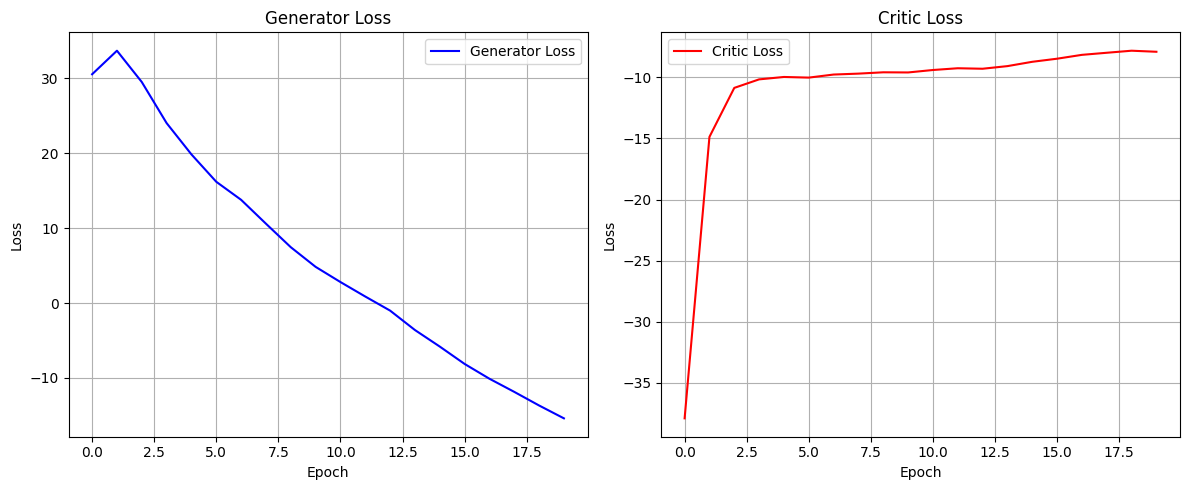


✅ GAN Training Complete!

📸 GENERATING SYNTHETIC IMAGES
  ✅ Mild_Demented: Saved 20 generated images
  ✅ Moderate_Demented: Saved 20 generated images
  ✅ No_Demented: Saved 20 generated images
  ✅ Very_Mild_Demented: Saved 20 generated images

✅ Generated images saved to: /content/drive/My Drive/GAN_Generated_Images_Stable

👁️  VISUALIZING REAL VS GENERATED


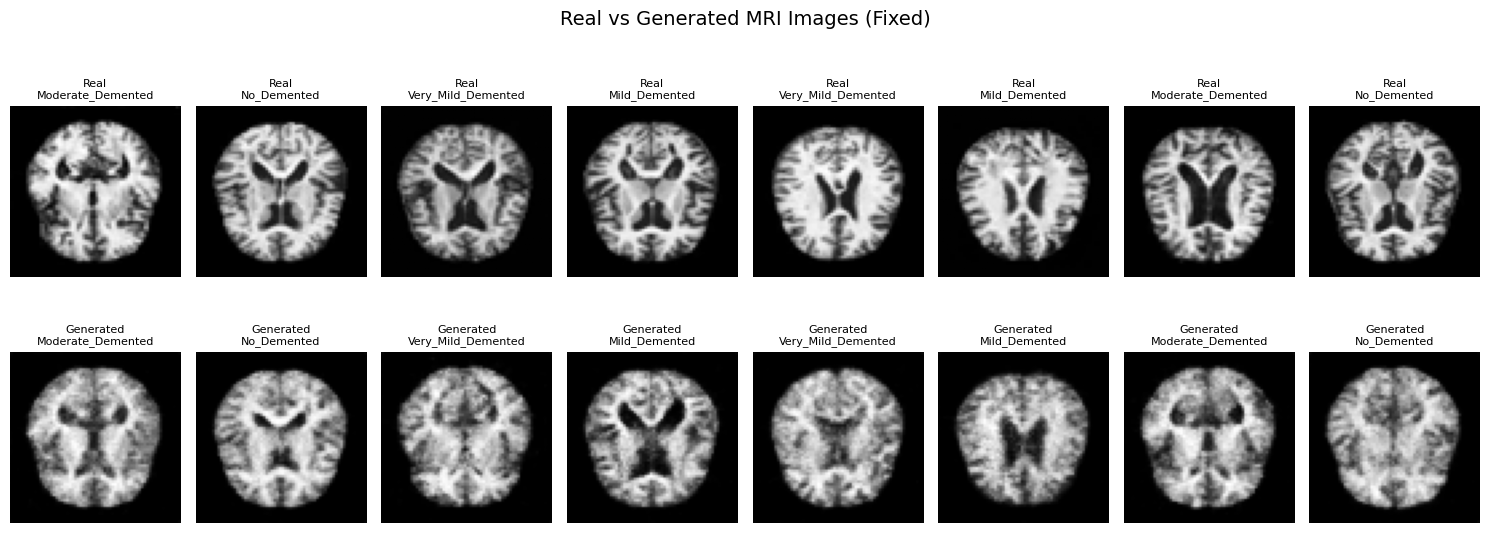


🎉 TRAINING COMPLETE!


In [ ]:
# ============================================
# FIXED WGAN-GP (BatchNorm -> GroupNorm in critic)
# ============================================
#
# ROOT CAUSE OF THE EXPLODING LOSSES:
# The critic used nn.BatchNorm2d. WGAN-GP's gradient penalty requires the
# critic's output for a given (interpolated) sample to depend ONLY on that
# sample. BatchNorm violates this because it normalizes using the batch's
# mean/variance, so gradients leak across samples in the batch. That makes
# the gradient-penalty estimate wrong, and the critic and generator losses
# feed off each other and diverge (which is exactly the G=18 -> 2700,
# C=-25 -> -5400 spiral you saw by epoch 6-7).
#
# Fix: use GroupNorm (or InstanceNorm) in the critic instead — both
# normalize per-sample, per-channel, so they don't break the GP assumption.
# BatchNorm in the GENERATOR is fine and was left unchanged.

from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")

# ============================================
# YOUR DATASET PATH
# ============================================

DATA_PATH = "/content/drive/My Drive/Alzhiemer_GAN_federated/Alzhiemer's_disease"
class_names = ['Mild_Demented', 'Moderate_Demented', 'No_Demented', 'Very_Mild_Demented']

print(f"📂 Dataset path: {DATA_PATH}")

# ============================================
# LOAD DATASET (unchanged)
# ============================================

class MRIDataset(Dataset):
    def __init__(self, image_paths, labels):
        self.image_paths = image_paths
        self.labels = labels

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        try:
            img = Image.open(img_path).convert('L')
            img = img.resize((64, 64))
            img = np.array(img, dtype=np.float32)
            img = (img / 127.5) - 1
            img = torch.from_numpy(img).unsqueeze(0)
        except Exception:
            img = torch.zeros(1, 64, 64)

        return img, label

def load_mri_data(data_dir):
    all_paths = []
    all_labels = []

    print("\n📂 Loading dataset...")

    for label, class_name in enumerate(class_names):
        class_dir = os.path.join(data_dir, class_name)
        if os.path.exists(class_dir):
            files = [f for f in os.listdir(class_dir)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            for img_file in files:
                all_paths.append(os.path.join(class_dir, img_file))
                all_labels.append(label)
            print(f"  ✅ {class_name}: {len(files)} images")

    print(f"\n📊 Total images: {len(all_paths)}")
    return all_paths, all_labels

def train_test_split(paths, labels, train_ratio=0.7):
    class_indices = {i: [] for i in range(4)}
    for idx, label in enumerate(labels):
        class_indices[label].append(idx)

    train_indices = []
    test_indices = []

    for label, indices in class_indices.items():
        np.random.shuffle(indices)
        split_point = int(len(indices) * train_ratio)
        train_indices.extend(indices[:split_point])
        test_indices.extend(indices[split_point:])

    train_paths = [paths[i] for i in train_indices]
    train_labels = [labels[i] for i in train_indices]
    test_paths = [paths[i] for i in test_indices]
    test_labels = [labels[i] for i in test_indices]

    return train_paths, train_labels, test_paths, test_labels

all_paths, all_labels = load_mri_data(DATA_PATH)

train_paths, train_labels, test_paths, test_labels = train_test_split(
    all_paths, all_labels, train_ratio=0.7
)

print(f"\n📊 Split complete:")
print(f"   Train: {len(train_paths)} images")
print(f"   Test: {len(test_paths)} images")

train_dataset = MRIDataset(train_paths, train_labels)
test_dataset = MRIDataset(test_paths, test_labels)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"   Train batches: {len(train_loader)}")
print(f"   Test batches: {len(test_loader)}")

# ============================================
# GENERATOR (unchanged — BatchNorm here is fine)
# ============================================

class SimpleGenerator(nn.Module):
    def __init__(self, latent_dim=100, num_classes=4):
        super(SimpleGenerator, self).__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        self.label_embedding = nn.Embedding(num_classes, latent_dim)
        self.fc = nn.Linear(latent_dim * 2, 256 * 4 * 4)

        self.main = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.ConvTranspose2d(32, 1, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z, labels):
        label_emb = self.label_embedding(labels)
        z = torch.cat([z, label_emb], dim=1)
        out = self.fc(z)
        out = out.view(out.size(0), 256, 4, 4)
        img = self.main(out)
        return img

# ============================================
# CRITIC — FIXED: BatchNorm2d -> GroupNorm, Dropout removed
# ============================================

class SimpleCritic(nn.Module):
    def __init__(self, num_classes=4, img_size=64):
        super(SimpleCritic, self).__init__()
        self.num_classes = num_classes
        self.img_size = img_size

        self.label_embedding = nn.Embedding(num_classes, img_size * img_size)

        # GroupNorm normalizes per-sample (splits channels into groups and
        # normalizes within each sample), unlike BatchNorm which normalizes
        # across the batch. This keeps the gradient penalty's per-sample
        # assumption valid. No norm on the first layer (standard WGAN-GP
        # practice, same reason DCGAN skips BN on the first D layer).
        self.main = nn.Sequential(
            nn.Conv2d(2, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.GroupNorm(8, 128),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.GroupNorm(8, 256),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.GroupNorm(8, 512),
            nn.LeakyReLU(0.2, True),
        )
        self.fc = nn.Linear(512 * 4 * 4, 1)

    def forward(self, img, labels):
        label_emb = self.label_embedding(labels)
        label_emb = label_emb.view(label_emb.size(0), 1, self.img_size, self.img_size)
        d_in = torch.cat([img, label_emb], dim=1)
        out = self.main(d_in)
        out = out.view(out.size(0), -1)
        score = self.fc(out)
        return score

# ============================================
# WGAN-GP TRAINER — lr tuned back to spec, gradient clipping,
# and a divergence guard so it stops itself instead of hanging forever
# ============================================

class StableWGAN_GP:
    def __init__(self, latent_dim=100, num_classes=4, lambda_gp=10, n_critic=5,
                 lr_g=0.0001, lr_c=0.0001, device=None, loss_explode_threshold=200.0):
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.lambda_gp = lambda_gp
        self.n_critic = n_critic
        self.device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.loss_explode_threshold = loss_explode_threshold

        self.generator = SimpleGenerator(latent_dim, num_classes).to(self.device)
        self.critic = SimpleCritic(num_classes).to(self.device)

        self.optimizer_G = optim.Adam(self.generator.parameters(), lr=lr_g, betas=(0.5, 0.9))
        self.optimizer_C = optim.Adam(self.critic.parameters(), lr=lr_c, betas=(0.5, 0.9))

        self.g_losses = []
        self.c_losses = []

    def compute_gradient_penalty(self, real_imgs, fake_imgs, labels):
        batch_size = real_imgs.size(0)
        alpha = torch.rand(batch_size, 1, 1, 1).to(self.device)
        alpha = alpha.expand_as(real_imgs)

        interpolated = alpha * real_imgs + (1 - alpha) * fake_imgs
        interpolated.requires_grad_(True)

        critic_interpolated = self.critic(interpolated, labels)

        grad = torch.autograd.grad(
            outputs=critic_interpolated,
            inputs=interpolated,
            grad_outputs=torch.ones_like(critic_interpolated),
            create_graph=True,
            retain_graph=True,
        )[0]

        grad_norm = grad.view(batch_size, -1).norm(2, dim=1)
        gradient_penalty = ((grad_norm - 1) ** 2).mean()
        return gradient_penalty

    def train_step(self, real_imgs, labels):
        batch_size = real_imgs.size(0)

        for _ in range(self.n_critic):
            self.optimizer_C.zero_grad()
            z = torch.randn(batch_size, self.latent_dim).to(self.device)
            fake_imgs = self.generator(z, labels)

            real_score = self.critic(real_imgs, labels)
            fake_score = self.critic(fake_imgs.detach(), labels)
            gradient_penalty = self.compute_gradient_penalty(real_imgs, fake_imgs, labels)

            critic_loss = fake_score.mean() - real_score.mean() + self.lambda_gp * gradient_penalty
            critic_loss.backward()
            # gradient clipping: extra safety net against spikes
            torch.nn.utils.clip_grad_norm_(self.critic.parameters(), max_norm=10.0)
            self.optimizer_C.step()

        self.optimizer_G.zero_grad()
        z = torch.randn(batch_size, self.latent_dim).to(self.device)
        fake_imgs = self.generator(z, labels)
        gen_loss = -self.critic(fake_imgs, labels).mean()
        gen_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.generator.parameters(), max_norm=10.0)
        self.optimizer_G.step()

        return gen_loss.item(), critic_loss.item()

    def train(self, dataloader, epochs=30, save_interval=5):
        print(f"\n{'='*60}")
        print(f"FIXED WGAN-GP TRAINING - 64x64 IMAGES")
        print(f"{'='*60}")
        print(f"Device: {self.device}")
        print(f"Epochs: {epochs}")
        print(f"Batch size: {dataloader.batch_size}")
        print(f"Learning Rate: {self.optimizer_G.param_groups[0]['lr']}")
        print(f"n_critic: {self.n_critic}")
        print(f"lambda_gp: {self.lambda_gp}")
        print(f"{'='*60}\n")

        for epoch in range(epochs):
            epoch_g_loss = 0
            epoch_c_loss = 0
            num_batches = 0

            progress_bar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{epochs}')
            for batch_idx, (imgs, labels) in enumerate(progress_bar):
                imgs = imgs.to(self.device)
                labels = labels.to(self.device)

                g_loss, c_loss = self.train_step(imgs, labels)

                # Divergence guard: stop immediately instead of burning
                # GPU hours on a training run that's already blown up.
                if abs(g_loss) > self.loss_explode_threshold or abs(c_loss) > self.loss_explode_threshold:
                    print(f"\n⚠️  Loss exploded (G={g_loss:.2f}, C={c_loss:.2f}) "
                          f"at epoch {epoch+1}, batch {batch_idx+1}. Stopping early.")
                    print("If this triggers again after the BatchNorm->GroupNorm fix, "
                          "try lowering lr_g/lr_c further (e.g. 0.00005) or lambda_gp.")
                    self.save_model(epoch + 1, save_dir='checkpoints_stable_diverged')
                    self.plot_losses()
                    return self.g_losses, self.c_losses

                epoch_g_loss += g_loss
                epoch_c_loss += c_loss
                num_batches += 1

                progress_bar.set_postfix({'G': f'{g_loss:.4f}', 'C': f'{c_loss:.4f}'})

            avg_g_loss = epoch_g_loss / num_batches
            avg_c_loss = epoch_c_loss / num_batches
            self.g_losses.append(avg_g_loss)
            self.c_losses.append(avg_c_loss)

            print(f'Epoch [{epoch+1}/{epochs}] - G_loss: {avg_g_loss:.4f}, C_loss: {avg_c_loss:.4f}')

            if (epoch + 1) % save_interval == 0:
                self.save_samples(epoch + 1)
                self.save_model(epoch + 1)

        self.save_samples(epochs)
        self.save_model(epochs)
        self.plot_losses()

        return self.g_losses, self.c_losses

    def generate_images(self, labels, num_images_per_class=10):
        self.generator.eval()
        generated_images = []

        with torch.no_grad():
            for label in range(self.num_classes):
                label_tensor = torch.full((num_images_per_class,), label, dtype=torch.long).to(self.device)
                z = torch.randn(num_images_per_class, self.latent_dim).to(self.device)
                fake_imgs = self.generator(z, label_tensor)
                generated_images.append(fake_imgs)

        return torch.cat(generated_images, dim=0)

    def save_samples(self, epoch, save_dir='gan_samples_stable'):
        os.makedirs(save_dir, exist_ok=True)

        self.generator.eval()
        fig, axes = plt.subplots(4, 4, figsize=(12, 12))

        with torch.no_grad():
            for label in range(self.num_classes):
                labels = torch.full((4,), label, dtype=torch.long).to(self.device)
                z = torch.randn(4, self.latent_dim).to(self.device)
                imgs = self.generator(z, labels)

                for j in range(4):
                    img = imgs[j].cpu().numpy().squeeze()
                    img = (img + 1) / 2
                    axes[label, j].imshow(img, cmap='gray')
                    axes[label, j].axis('off')
                    if j == 0:
                        axes[label, j].set_ylabel(class_names[label], fontsize=10)

        plt.suptitle(f'Generated Samples - Epoch {epoch}', fontsize=14)
        plt.tight_layout()
        plt.savefig(f'{save_dir}/samples_epoch_{epoch}.png', dpi=150)
        plt.close()
        self.generator.train()

    def save_model(self, epoch, save_dir='checkpoints_stable'):
        os.makedirs(save_dir, exist_ok=True)
        torch.save({
            'generator_state_dict': self.generator.state_dict(),
            'critic_state_dict': self.critic.state_dict(),
            'optimizer_G_state_dict': self.optimizer_G.state_dict(),
            'optimizer_C_state_dict': self.optimizer_C.state_dict(),
            'epoch': epoch,
            'g_losses': self.g_losses,
            'c_losses': self.c_losses,
        }, f'{save_dir}/wgan_gp_epoch_{epoch}.pth')
        print(f"✅ Model saved at {save_dir}/wgan_gp_epoch_{epoch}.pth")

    def plot_losses(self):
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(self.g_losses, label='Generator Loss', color='blue')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Generator Loss')
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(self.c_losses, label='Critic Loss', color='red')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Critic Loss')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.savefig('training_losses_stable.png', dpi=150)
        plt.show()

# ============================================
# TRAIN
# ============================================

print("\n" + "="*60)
print("🚀 STARTING FIXED GAN TRAINING")
print("="*60)

trainer = StableWGAN_GP(
    latent_dim=100,
    num_classes=4,
    lambda_gp=10,
    n_critic=5,
    lr_g=0.0001,   # lowered from 0.0002 per WGAN-GP paper recommendation
    lr_c=0.0001,
    device=device
)

EPOCHS = 20
g_losses, c_losses = trainer.train(train_loader, epochs=EPOCHS, save_interval=5)

print("\n✅ GAN Training Complete!")

# ============================================
# GENERATE AND SAVE IMAGES
# ============================================

print("\n" + "="*60)
print("📸 GENERATING SYNTHETIC IMAGES")
print("="*60)

num_per_class = 20
synthetic_images = trainer.generate_images(labels=torch.arange(4), num_images_per_class=num_per_class)

output_dir = '/content/drive/My Drive/GAN_Generated_Images_Stable'
os.makedirs(output_dir, exist_ok=True)

for label in range(4):
    class_dir = os.path.join(output_dir, class_names[label])
    os.makedirs(class_dir, exist_ok=True)

    start_idx = label * num_per_class
    end_idx = start_idx + num_per_class
    class_images = synthetic_images[start_idx:end_idx]

    for i, img_tensor in enumerate(class_images):
        img_np = img_tensor.cpu().numpy().squeeze()
        img_np = (img_np + 1) / 2 * 255
        img_np = img_np.astype(np.uint8)

        img = Image.fromarray(img_np, mode='L')
        img.save(os.path.join(class_dir, f'generated_{i+1}.png'))

    print(f"  ✅ {class_names[label]}: Saved {num_per_class} generated images")

print(f"\n✅ Generated images saved to: {output_dir}")

# ============================================
# VISUALIZE RESULTS
# ============================================

print("\n" + "="*60)
print("👁️  VISUALIZING REAL VS GENERATED")
print("="*60)

def visualize_real_vs_generated(train_loader, trainer, num_samples=8):
    real_imgs, real_labels = next(iter(train_loader))
    real_imgs = real_imgs[:num_samples]
    real_labels = real_labels[:num_samples]

    z = torch.randn(num_samples, trainer.latent_dim).to(trainer.device)
    labels = real_labels.to(trainer.device)
    trainer.generator.eval()
    with torch.no_grad():
        fake_imgs = trainer.generator(z, labels)
    trainer.generator.train()

    fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))

    for i in range(num_samples):
        real = real_imgs[i].cpu().numpy().squeeze()
        real = (real + 1) / 2
        axes[0, i].imshow(real, cmap='gray')
        axes[0, i].set_title(f'Real\n{class_names[real_labels[i].item()]}', fontsize=8)
        axes[0, i].axis('off')

        fake = fake_imgs[i].cpu().numpy().squeeze()
        fake = (fake + 1) / 2
        axes[1, i].imshow(fake, cmap='gray')
        axes[1, i].set_title(f'Generated\n{class_names[labels[i].item()]}', fontsize=8)
        axes[1, i].axis('off')

    plt.suptitle('Real vs Generated MRI Images (Fixed)', fontsize=14)
    plt.tight_layout()
    plt.savefig('real_vs_generated_stable.png', dpi=150)
    plt.show()

visualize_real_vs_generated(train_loader, trainer, min(8, len(train_paths)))

print("\n" + "="*60)
print("🎉 TRAINING COMPLETE!")
print("="*60)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1. VISUAL GRID (real vs generated)


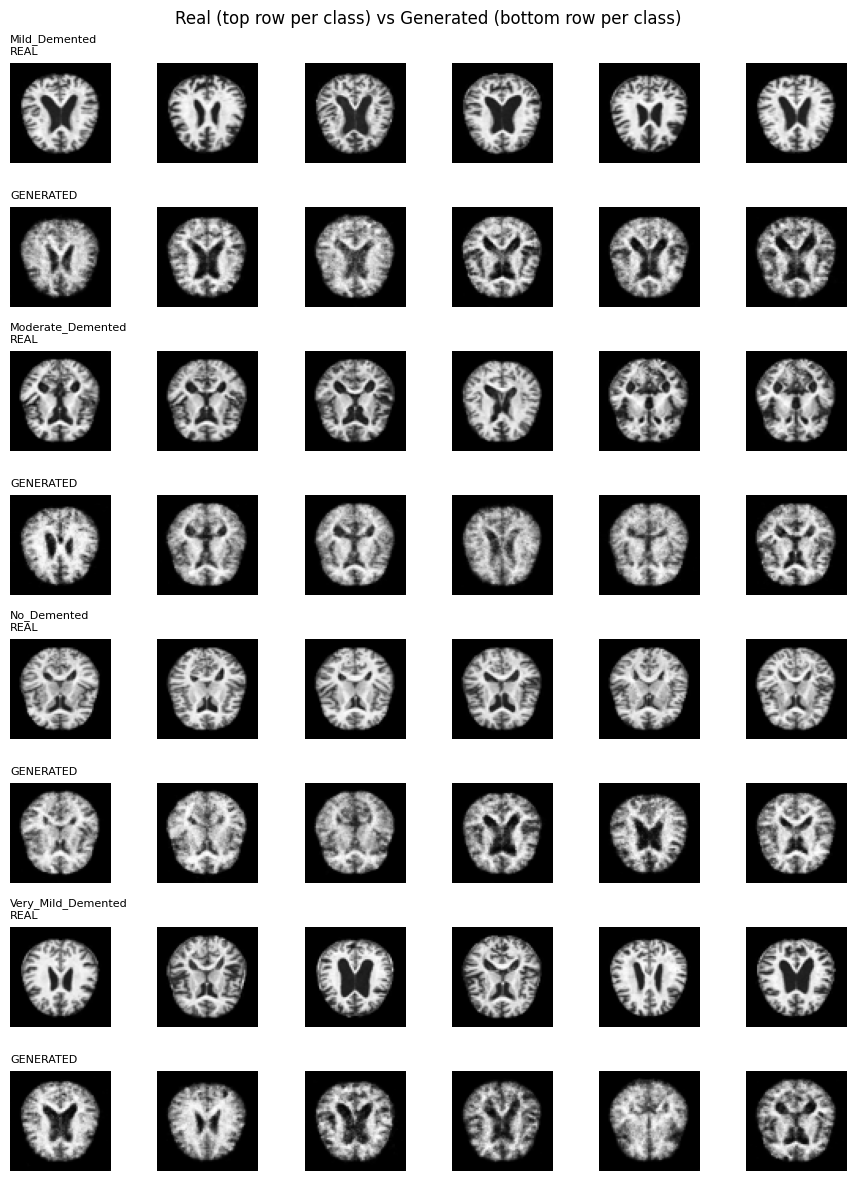


2. MODE COLLAPSE CHECK
Class                Real diversity   Fake diversity   Ratio (fake/real)
----------------------------------------------------------------------
Mild_Demented        2796.718         2682.513         0.959
Moderate_Demented    2897.072         2434.784         0.840
No_Demented          2422.234         2583.366         1.067
Very_Mild_Demented   3243.103         2764.391         0.852

3. PIXEL STATISTICS

Class                Real mean/std        Fake mean/std       
-----------------------------------------------------------------
Mild_Demented        68.0 / 81.1           68.5 / 79.6
Moderate_Demented    71.3 / 82.7           70.2 / 78.8
No_Demented          74.0 / 82.9           76.0 / 84.5
Very_Mild_Demented   69.3 / 81.7           66.2 / 77.2


In [ ]:
# ============================================
# GAN QUALITY CHECK — using saved images from Drive
# No checkpoint or trainer needed — just reads the PNG files
# you already generated and saved to Drive.
# ============================================

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from itertools import combinations

class_names = ['Mild_Demented', 'Moderate_Demented', 'No_Demented', 'Very_Mild_Demented']

REAL_DATA_PATH = "/content/drive/My Drive/Alzhiemer_GAN_federated/Alzhiemer's_disease"
FAKE_DATA_PATH = "/content/drive/My Drive/GAN_Generated_Images_Stable"

def load_images_from_folder(folder, max_images=30, size=(64, 64)):
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    files = files[:max_images]
    imgs = []
    for f in files:
        img = Image.open(os.path.join(folder, f)).convert('L').resize(size)
        imgs.append(np.array(img, dtype=np.float32))
    return np.stack(imgs) if imgs else np.zeros((0, *size))

# ---------------------------------------------
# 1. VISUAL GRID: real vs generated, side by side per class
# ---------------------------------------------
def show_real_vs_fake_grid(n_samples=6):
    fig, axes = plt.subplots(len(class_names) * 2, n_samples, figsize=(n_samples * 1.5, len(class_names) * 3))

    for c, cname in enumerate(class_names):
        real_imgs = load_images_from_folder(os.path.join(REAL_DATA_PATH, cname), max_images=n_samples)
        fake_imgs = load_images_from_folder(os.path.join(FAKE_DATA_PATH, cname), max_images=n_samples)

        for j in range(n_samples):
            row_real = c * 2
            row_fake = c * 2 + 1

            if j < len(real_imgs):
                axes[row_real, j].imshow(real_imgs[j] / 255.0, cmap='gray')
            axes[row_real, j].axis('off')
            if j == 0:
                axes[row_real, j].set_title(f'{cname}\nREAL', fontsize=8, loc='left')

            if j < len(fake_imgs):
                axes[row_fake, j].imshow(fake_imgs[j] / 255.0, cmap='gray')
            axes[row_fake, j].axis('off')
            if j == 0:
                axes[row_fake, j].set_title('GENERATED', fontsize=8, loc='left')

    plt.suptitle('Real (top row per class) vs Generated (bottom row per class)')
    plt.tight_layout()
    plt.savefig('/content/quality_check_grid.png', dpi=150)
    plt.show()

# ---------------------------------------------
# 2. MODE COLLAPSE CHECK: pairwise diversity, real vs fake
# ---------------------------------------------
def diversity_score(images):
    flat = images.reshape(images.shape[0], -1)
    dists = []
    for i, j in combinations(range(len(flat)), 2):
        dists.append(np.linalg.norm(flat[i] - flat[j]))
    return float(np.mean(dists)) if dists else 0.0

def check_mode_collapse():
    print(f"{'Class':<20} {'Real diversity':<16} {'Fake diversity':<16} {'Ratio (fake/real)'}")
    print("-" * 70)
    for cname in class_names:
        real_imgs = load_images_from_folder(os.path.join(REAL_DATA_PATH, cname), max_images=20)
        fake_imgs = load_images_from_folder(os.path.join(FAKE_DATA_PATH, cname), max_images=20)

        real_div = diversity_score(real_imgs)
        fake_div = diversity_score(fake_imgs)
        ratio = fake_div / real_div if real_div > 0 else float('nan')
        flag = "  ⚠️ possible mode collapse" if ratio < 0.3 else ""
        print(f"{cname:<20} {real_div:<16.3f} {fake_div:<16.3f} {ratio:.3f}{flag}")

# ---------------------------------------------
# 3. PIXEL STATISTICS: real vs fake mean/std per class
# ---------------------------------------------
def compare_pixel_stats():
    print(f"\n{'Class':<20} {'Real mean/std':<20} {'Fake mean/std':<20}")
    print("-" * 65)
    for cname in class_names:
        real_imgs = load_images_from_folder(os.path.join(REAL_DATA_PATH, cname), max_images=100)
        fake_imgs = load_images_from_folder(os.path.join(FAKE_DATA_PATH, cname), max_images=100)

        r_mean, r_std = real_imgs.mean(), real_imgs.std()
        f_mean, f_std = fake_imgs.mean(), fake_imgs.std()
        print(f"{cname:<20} {r_mean:.1f} / {r_std:.1f}{'':<10} {f_mean:.1f} / {f_std:.1f}")

# ---------------------------------------------
# RUN ALL CHECKS
# ---------------------------------------------
print("=" * 60)
print("1. VISUAL GRID (real vs generated)")
print("=" * 60)
show_real_vs_fake_grid(n_samples=6)

print("\n" + "=" * 60)
print("2. MODE COLLAPSE CHECK")
print("=" * 60)
check_mode_collapse()

print("\n" + "=" * 60)
print("3. PIXEL STATISTICS")
print("=" * 60)
compare_pixel_stats()

Mounted at /content/drive
✅ Using device: cuda
📂 Dataset path: /content/drive/My Drive/Alzhiemer_GAN_federated/Alzhiemer's_disease

📂 Loading dataset...
  ✅ Mild_Demented: 2624 images
  ✅ Moderate_Demented: 2624 images
  ✅ No_Demented: 2624 images
  ✅ Very_Mild_Demented: 2624 images

📊 Total images: 10496

📊 Split complete:
   Train: 7344 images
   Test: 3152 images
   Train batches: 114
   Test batches: 50

🚀 STARTING FIXED GAN TRAINING

FIXED WGAN-GP TRAINING - 64x64 IMAGES
Device: cuda
Epochs: 20
Batch size: 64
Learning Rate: 0.0001
n_critic: 5
lambda_gp: 10



Epoch 1/20: 100%|██████████| 114/114 [36:59<00:00, 19.47s/it, G=29.8971, C=-19.4376]


Epoch [1/20] - G_loss: 30.4239, C_loss: -37.8983


Epoch 2/20: 100%|██████████| 114/114 [01:27<00:00,  1.30it/s, G=25.9025, C=-12.0781]


Epoch [2/20] - G_loss: 33.7240, C_loss: -14.8197


...

Epoch [18/20] - G_loss: -8.8235, C_loss: -8.3303


Epoch 19/20: 100%|██████████| 114/114 [01:14<00:00,  1.52it/s, G=-10.1230, C=-7.9007]


Epoch [19/20] - G_loss: -10.1078, C_loss: -8.1453


Epoch 20/20: 100%|██████████| 114/114 [01:14<00:00,  1.52it/s, G=-12.8878, C=-6.6798]


Epoch [20/20] - G_loss: -12.0376, C_loss: -7.9659
✅ Model saved at checkpoints_stable/wgan_gp_epoch_20.pth
✅ Model saved at checkpoints_stable/wgan_gp_epoch_20.pth


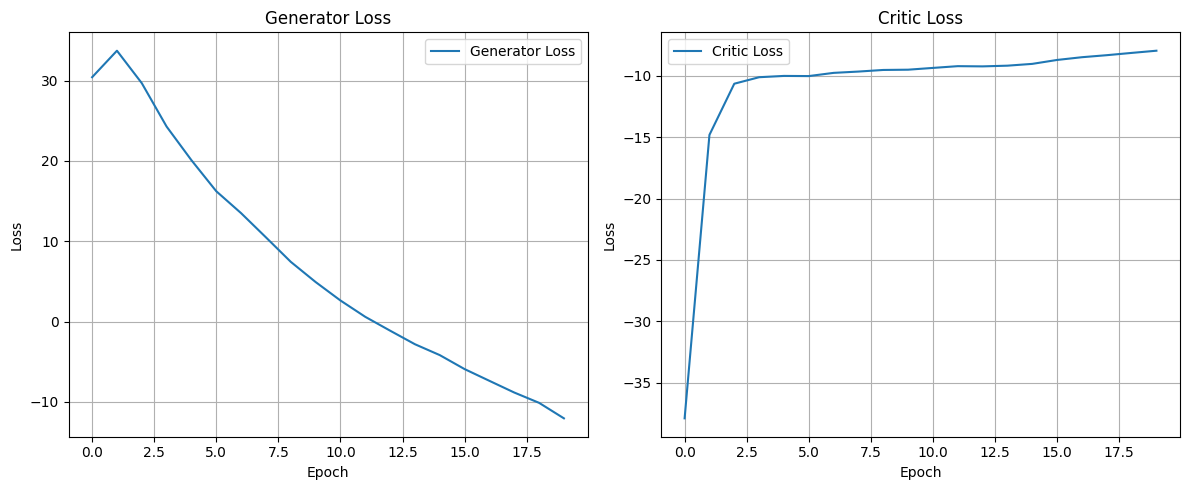


✅ GAN Training Complete!

📸 GENERATING 480 IMAGES PER CLASS

GENERATING SYNTHETIC MRI IMAGES
Images per class: 480
Number of classes: 4
Total images: 1920

Generating Mild_Demented...
  ✅ Mild_Demented: 480 images

Generating Moderate_Demented...
  ✅ Moderate_Demented: 480 images

Generating No_Demented...
  ✅ No_Demented: 480 images

Generating Very_Mild_Demented...
  ✅ Very_Mild_Demented: 480 images

💾 Saving Mild_Demented...


Mild_Demented: 100%|██████████| 480/480 [00:03<00:00, 121.47it/s]


  ✅ Mild_Demented: 480 images saved

💾 Saving Moderate_Demented...


Moderate_Demented: 100%|██████████| 480/480 [00:04<00:00, 114.31it/s]


  ✅ Moderate_Demented: 480 images saved

💾 Saving No_Demented...


No_Demented: 100%|██████████| 480/480 [00:04<00:00, 106.09it/s]


  ✅ No_Demented: 480 images saved

💾 Saving Very_Mild_Demented...


Very_Mild_Demented: 100%|██████████| 480/480 [00:04<00:00, 115.20it/s]


  ✅ Very_Mild_Demented: 480 images saved

🎉 IMAGE GENERATION COMPLETE!

📂 Output folder:
/content/drive/My Drive/GAN_Generated_Images_480

📊 Generated images:
   Mild_Demented: 480 images
   Moderate_Demented: 480 images
   No_Demented: 480 images
   Very_Mild_Demented: 480 images

🧮 Total generated: 1920 images

👁️ VISUALIZING REAL VS GENERATED


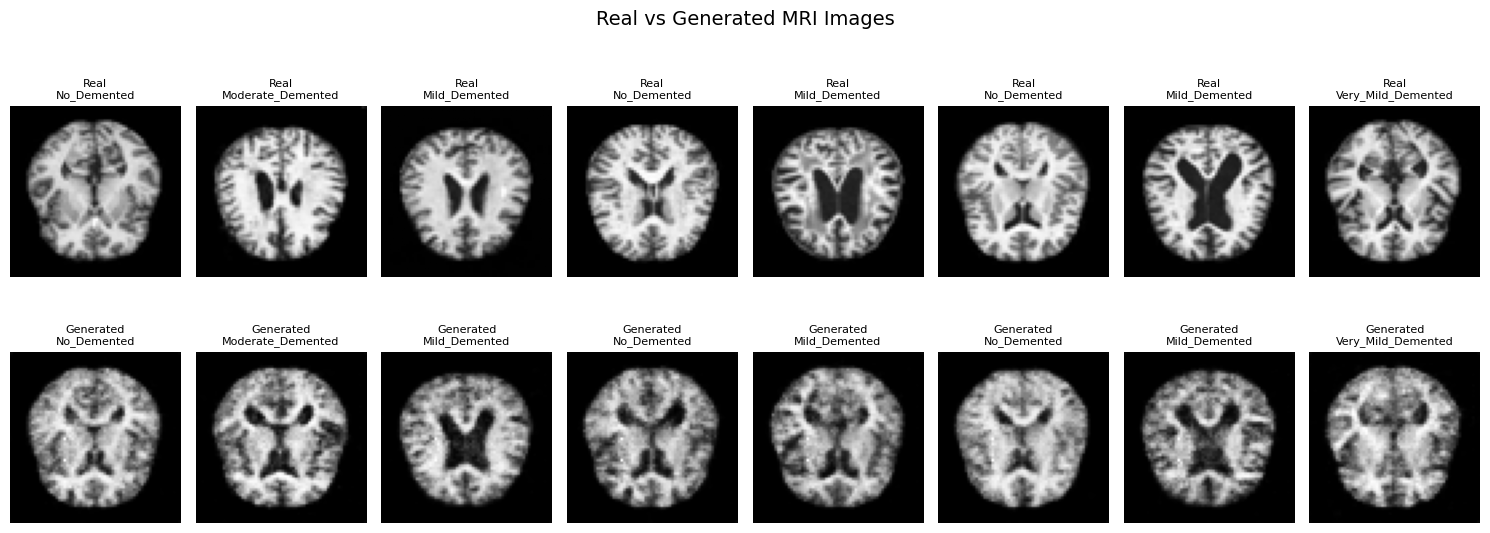


🎉 TRAINING + GENERATION COMPLETE!

You generated:
Mild_Demented       → 480 images
Moderate_Demented   → 480 images
No_Demented         → 480 images
Very_Mild_Demented  → 480 images

Total → 1,920 synthetic images

Saved at:
/content/drive/My Drive/GAN_Generated_Images_480


In [ ]:
# ============================================
# FIXED WGAN-GP
# BatchNorm -> GroupNorm in Critic
# Generate 480 images per class
# ============================================

from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')


# ============================================
# SET SEED
# ============================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


# ============================================
# DEVICE
# ============================================

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print(f"✅ Using device: {device}")


# ============================================
# DATASET PATH
# ============================================

DATA_PATH = "/content/drive/My Drive/Alzhiemer_GAN_federated/Alzhiemer's_disease"

class_names = [
    'Mild_Demented',
    'Moderate_Demented',
    'No_Demented',
    'Very_Mild_Demented'
]

print(f"📂 Dataset path: {DATA_PATH}")


# ============================================
# DATASET CLASS
# ============================================

class MRIDataset(Dataset):

    def __init__(self, image_paths, labels):
        self.image_paths = image_paths
        self.labels = labels

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        img_path = self.image_paths[idx]
        label = self.labels[idx]

        try:

            img = Image.open(img_path).convert('L')

            img = img.resize((64, 64))

            img = np.array(
                img,
                dtype=np.float32
            )

            # Normalize to [-1, 1]
            img = (img / 127.5) - 1

            img = torch.from_numpy(img).unsqueeze(0)

        except Exception:

            img = torch.zeros(
                1,
                64,
                64
            )

        return img, label


# ============================================
# LOAD MRI DATA
# ============================================

def load_mri_data(data_dir):

    all_paths = []
    all_labels = []

    print("\n📂 Loading dataset...")

    for label, class_name in enumerate(class_names):

        class_dir = os.path.join(
            data_dir,
            class_name
        )

        if os.path.exists(class_dir):

            files = [
                f for f in os.listdir(class_dir)
                if f.lower().endswith(
                    ('.jpg', '.jpeg', '.png')
                )
            ]

            for img_file in files:

                all_paths.append(
                    os.path.join(
                        class_dir,
                        img_file
                    )
                )

                all_labels.append(label)

            print(
                f"  ✅ {class_name}: {len(files)} images"
            )

    print(
        f"\n📊 Total images: {len(all_paths)}"
    )

    return all_paths, all_labels


# ============================================
# TRAIN / TEST SPLIT
# ============================================

def train_test_split(
    paths,
    labels,
    train_ratio=0.7
):

    class_indices = {
        i: [] for i in range(4)
    }

    for idx, label in enumerate(labels):

        class_indices[label].append(idx)

    train_indices = []
    test_indices = []

    for label, indices in class_indices.items():

        np.random.shuffle(indices)

        split_point = int(
            len(indices) * train_ratio
        )

        train_indices.extend(
            indices[:split_point]
        )

        test_indices.extend(
            indices[split_point:]
        )

    train_paths = [
        paths[i] for i in train_indices
    ]

    train_labels = [
        labels[i] for i in train_indices
    ]

    test_paths = [
        paths[i] for i in test_indices
    ]

    test_labels = [
        labels[i] for i in test_indices
    ]

    return (
        train_paths,
        train_labels,
        test_paths,
        test_labels
    )


# ============================================
# LOAD DATA
# ============================================

all_paths, all_labels = load_mri_data(
    DATA_PATH
)

(
    train_paths,
    train_labels,
    test_paths,
    test_labels
) = train_test_split(
    all_paths,
    all_labels,
    train_ratio=0.7
)

print("\n📊 Split complete:")

print(
    f"   Train: {len(train_paths)} images"
)

print(
    f"   Test: {len(test_paths)} images"
)


# ============================================
# DATASET + DATALOADER
# ============================================

train_dataset = MRIDataset(
    train_paths,
    train_labels
)

test_dataset = MRIDataset(
    test_paths,
    test_labels
)

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print(
    f"   Train batches: {len(train_loader)}"
)

print(
    f"   Test batches: {len(test_loader)}"
)


# ============================================
# GENERATOR
# ============================================

class SimpleGenerator(nn.Module):

    def __init__(
        self,
        latent_dim=100,
        num_classes=4
    ):

        super(SimpleGenerator, self).__init__()

        self.latent_dim = latent_dim
        self.num_classes = num_classes

        self.label_embedding = nn.Embedding(
            num_classes,
            latent_dim
        )

        self.fc = nn.Linear(
            latent_dim * 2,
            256 * 4 * 4
        )

        self.main = nn.Sequential(

            nn.ConvTranspose2d(
                256,
                128,
                4,
                2,
                1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(True),

            nn.ConvTranspose2d(
                128,
                64,
                4,
                2,
                1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(True),

            nn.ConvTranspose2d(
                64,
                32,
                4,
                2,
                1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(True),

            nn.ConvTranspose2d(
                32,
                1,
                4,
                2,
                1
            ),

            nn.Tanh()
        )


    def forward(
        self,
        z,
        labels
    ):

        label_emb = self.label_embedding(
            labels
        )

        z = torch.cat(
            [z, label_emb],
            dim=1
        )

        out = self.fc(z)

        out = out.view(
            out.size(0),
            256,
            4,
            4
        )

        img = self.main(out)

        return img


# ============================================
# CRITIC
# BatchNorm replaced with GroupNorm
# ============================================

class SimpleCritic(nn.Module):

    def __init__(
        self,
        num_classes=4,
        img_size=64
    ):

        super(SimpleCritic, self).__init__()

        self.num_classes = num_classes
        self.img_size = img_size

        self.label_embedding = nn.Embedding(
            num_classes,
            img_size * img_size
        )

        self.main = nn.Sequential(

            nn.Conv2d(
                2,
                64,
                4,
                2,
                1
            ),

            nn.LeakyReLU(
                0.2,
                True
            ),

            nn.Conv2d(
                64,
                128,
                4,
                2,
                1
            ),

            nn.GroupNorm(
                8,
                128
            ),

            nn.LeakyReLU(
                0.2,
                True
            ),

            nn.Conv2d(
                128,
                256,
                4,
                2,
                1
            ),

            nn.GroupNorm(
                8,
                256
            ),

            nn.LeakyReLU(
                0.2,
                True
            ),

            nn.Conv2d(
                256,
                512,
                4,
                2,
                1
            ),

            nn.GroupNorm(
                8,
                512
            ),

            nn.LeakyReLU(
                0.2,
                True
            )
        )

        self.fc = nn.Linear(
            512 * 4 * 4,
            1
        )


    def forward(
        self,
        img,
        labels
    ):

        label_emb = self.label_embedding(
            labels
        )

        label_emb = label_emb.view(
            label_emb.size(0),
            1,
            self.img_size,
            self.img_size
        )

        d_in = torch.cat(
            [img, label_emb],
            dim=1
        )

        out = self.main(d_in)

        out = out.view(
            out.size(0),
            -1
        )

        score = self.fc(out)

        return score


# ============================================
# WGAN-GP TRAINER
# ============================================

class StableWGAN_GP:

    def __init__(
        self,
        latent_dim=100,
        num_classes=4,
        lambda_gp=10,
        n_critic=5,
        lr_g=0.0001,
        lr_c=0.0001,
        device=None,
        loss_explode_threshold=200.0
    ):

        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.lambda_gp = lambda_gp
        self.n_critic = n_critic

        self.device = (
            device
            if device
            else torch.device(
                'cuda'
                if torch.cuda.is_available()
                else 'cpu'
            )
        )

        self.loss_explode_threshold = (
            loss_explode_threshold
        )

        self.generator = SimpleGenerator(
            latent_dim,
            num_classes
        ).to(self.device)

        self.critic = SimpleCritic(
            num_classes
        ).to(self.device)

        self.optimizer_G = optim.Adam(
            self.generator.parameters(),
            lr=lr_g,
            betas=(0.5, 0.9)
        )

        self.optimizer_C = optim.Adam(
            self.critic.parameters(),
            lr=lr_c,
            betas=(0.5, 0.9)
        )

        self.g_losses = []
        self.c_losses = []


    # ========================================
    # GRADIENT PENALTY
    # ========================================

    def compute_gradient_penalty(
        self,
        real_imgs,
        fake_imgs,
        labels
    ):

        batch_size = real_imgs.size(0)

        alpha = torch.rand(
            batch_size,
            1,
            1,
            1
        ).to(self.device)

        alpha = alpha.expand_as(
            real_imgs
        )

        interpolated = (
            alpha * real_imgs
            +
            (1 - alpha) * fake_imgs
        )

        interpolated.requires_grad_(True)

        critic_interpolated = self.critic(
            interpolated,
            labels
        )

        grad = torch.autograd.grad(

            outputs=critic_interpolated,

            inputs=interpolated,

            grad_outputs=torch.ones_like(
                critic_interpolated
            ),

            create_graph=True,

            retain_graph=True
        )[0]

        grad_norm = grad.view(
            batch_size,
            -1
        ).norm(
            2,
            dim=1
        )

        gradient_penalty = (
            (grad_norm - 1) ** 2
        ).mean()

        return gradient_penalty


    # ========================================
    # TRAIN STEP
    # ========================================

    def train_step(
        self,
        real_imgs,
        labels
    ):

        batch_size = real_imgs.size(0)

        # -------------------------------
        # Train Critic
        # -------------------------------

        for _ in range(self.n_critic):

            self.optimizer_C.zero_grad()

            z = torch.randn(
                batch_size,
                self.latent_dim
            ).to(self.device)

            fake_imgs = self.generator(
                z,
                labels
            )

            real_score = self.critic(
                real_imgs,
                labels
            )

            fake_score = self.critic(
                fake_imgs.detach(),
                labels
            )

            gradient_penalty = (
                self.compute_gradient_penalty(
                    real_imgs,
                    fake_imgs,
                    labels
                )
            )

            critic_loss = (
                fake_score.mean()
                -
                real_score.mean()
                +
                self.lambda_gp * gradient_penalty
            )

            critic_loss.backward()

            torch.nn.utils.clip_grad_norm_(
                self.critic.parameters(),
                max_norm=10.0
            )

            self.optimizer_C.step()


        # -------------------------------
        # Train Generator
        # -------------------------------

        self.optimizer_G.zero_grad()

        z = torch.randn(
            batch_size,
            self.latent_dim
        ).to(self.device)

        fake_imgs = self.generator(
            z,
            labels
        )

        gen_loss = (
            -self.critic(
                fake_imgs,
                labels
            ).mean()
        )

        gen_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            self.generator.parameters(),
            max_norm=10.0
        )

        self.optimizer_G.step()

        return (
            gen_loss.item(),
            critic_loss.item()
        )


    # ========================================
    # TRAIN
    # ========================================

    def train(
        self,
        dataloader,
        epochs=20,
        save_interval=5
    ):

        print("\n" + "=" * 60)
        print(
            "FIXED WGAN-GP TRAINING - 64x64 IMAGES"
        )
        print("=" * 60)

        print(
            f"Device: {self.device}"
        )

        print(
            f"Epochs: {epochs}"
        )

        print(
            f"Batch size: {dataloader.batch_size}"
        )

        print(
            f"Learning Rate: "
            f"{self.optimizer_G.param_groups[0]['lr']}"
        )

        print(
            f"n_critic: {self.n_critic}"
        )

        print(
            f"lambda_gp: {self.lambda_gp}"
        )

        print("=" * 60 + "\n")


        for epoch in range(epochs):

            epoch_g_loss = 0
            epoch_c_loss = 0
            num_batches = 0

            progress_bar = tqdm(
                dataloader,
                desc=f'Epoch {epoch + 1}/{epochs}'
            )


            for batch_idx, (
                imgs,
                labels
            ) in enumerate(progress_bar):

                imgs = imgs.to(
                    self.device
                )

                labels = labels.to(
                    self.device
                )

                g_loss, c_loss = (
                    self.train_step(
                        imgs,
                        labels
                    )
                )


                # -------------------------------
                # Divergence Guard
                # -------------------------------

                if (
                    abs(g_loss)
                    >
                    self.loss_explode_threshold
                    or
                    abs(c_loss)
                    >
                    self.loss_explode_threshold
                ):

                    print(
                        f"\n⚠️ Loss exploded "
                        f"(G={g_loss:.2f}, "
                        f"C={c_loss:.2f}) "
                        f"at epoch "
                        f"{epoch + 1}, "
                        f"batch "
                        f"{batch_idx + 1}."
                    )

                    print(
                        "Stopping early."
                    )

                    self.save_model(
                        epoch + 1,
                        save_dir=
                        'checkpoints_stable_diverged'
                    )

                    self.plot_losses()

                    return (
                        self.g_losses,
                        self.c_losses
                    )


                epoch_g_loss += g_loss
                epoch_c_loss += c_loss

                num_batches += 1

                progress_bar.set_postfix(
                    {
                        'G': f'{g_loss:.4f}',
                        'C': f'{c_loss:.4f}'
                    }
                )


            avg_g_loss = (
                epoch_g_loss
                /
                num_batches
            )

            avg_c_loss = (
                epoch_c_loss
                /
                num_batches
            )

            self.g_losses.append(
                avg_g_loss
            )

            self.c_losses.append(
                avg_c_loss
            )

            print(
                f'Epoch [{epoch + 1}/{epochs}] '
                f'- G_loss: {avg_g_loss:.4f}, '
                f'C_loss: {avg_c_loss:.4f}'
            )


            if (
                (epoch + 1)
                %
                save_interval
                == 0
            ):

                self.save_samples(
                    epoch + 1
                )

                self.save_model(
                    epoch + 1
                )


        self.save_samples(
            epochs
        )

        self.save_model(
            epochs
        )

        self.plot_losses()

        return (
            self.g_losses,
            self.c_losses
        )


    # ========================================
    # GENERATE IMAGES
    # 480 PER CLASS
    # ========================================

    def generate_images(
        self,
        num_images_per_class=480
    ):

        self.generator.eval()

        generated_images = []

        print("\n" + "=" * 60)
        print(
            "GENERATING SYNTHETIC MRI IMAGES"
        )
        print("=" * 60)

        print(
            f"Images per class: "
            f"{num_images_per_class}"
        )

        print(
            f"Number of classes: "
            f"{self.num_classes}"
        )

        print(
            f"Total images: "
            f"{num_images_per_class * self.num_classes}"
        )

        print("=" * 60)


        with torch.no_grad():

            for label in range(
                self.num_classes
            ):

                print(
                    f"\nGenerating "
                    f"{class_names[label]}..."
                )

                label_tensor = torch.full(
                    (
                        num_images_per_class,
                    ),
                    label,
                    dtype=torch.long
                ).to(self.device)


                z = torch.randn(
                    num_images_per_class,
                    self.latent_dim
                ).to(self.device)


                fake_imgs = self.generator(
                    z,
                    label_tensor
                )


                generated_images.append(
                    fake_imgs.cpu()
                )


                print(
                    f"  ✅ "
                    f"{class_names[label]}: "
                    f"{num_images_per_class} images"
                )


        return torch.cat(
            generated_images,
            dim=0
        )


    # ========================================
    # SAVE SAMPLE IMAGES
    # ========================================

    def save_samples(
        self,
        epoch,
        save_dir='gan_samples_stable'
    ):

        os.makedirs(
            save_dir,
            exist_ok=True
        )

        self.generator.eval()

        fig, axes = plt.subplots(
            4,
            4,
            figsize=(12, 12)
        )


        with torch.no_grad():

            for label in range(
                self.num_classes
            ):

                labels = torch.full(
                    (4,),
                    label,
                    dtype=torch.long
                ).to(self.device)

                z = torch.randn(
                    4,
                    self.latent_dim
                ).to(self.device)

                imgs = self.generator(
                    z,
                    labels
                )


                for j in range(4):

                    img = (
                        imgs[j]
                        .cpu()
                        .numpy()
                        .squeeze()
                    )

                    img = (
                        img + 1
                    ) / 2


                    axes[
                        label,
                        j
                    ].imshow(
                        img,
                        cmap='gray'
                    )

                    axes[
                        label,
                        j
                    ].axis('off')


                    if j == 0:

                        axes[
                            label,
                            j
                        ].set_ylabel(
                            class_names[label],
                            fontsize=10
                        )


        plt.suptitle(
            f'Generated Samples - Epoch {epoch}',
            fontsize=14
        )

        plt.tight_layout()

        plt.savefig(
            f'{save_dir}/samples_epoch_{epoch}.png',
            dpi=150
        )

        plt.close()

        self.generator.train()


    # ========================================
    # SAVE MODEL
    # ========================================

    def save_model(
        self,
        epoch,
        save_dir='checkpoints_stable'
    ):

        os.makedirs(
            save_dir,
            exist_ok=True
        )

        torch.save(

            {
                'generator_state_dict':
                    self.generator.state_dict(),

                'critic_state_dict':
                    self.critic.state_dict(),

                'optimizer_G_state_dict':
                    self.optimizer_G.state_dict(),

                'optimizer_C_state_dict':
                    self.optimizer_C.state_dict(),

                'epoch':
                    epoch,

                'g_losses':
                    self.g_losses,

                'c_losses':
                    self.c_losses
            },

            f'{save_dir}/'
            f'wgan_gp_epoch_{epoch}.pth'
        )

        print(
            f"✅ Model saved at "
            f"{save_dir}/"
            f"wgan_gp_epoch_{epoch}.pth"
        )


    # ========================================
    # PLOT LOSSES
    # ========================================

    def plot_losses(self):

        plt.figure(
            figsize=(12, 5)
        )


        plt.subplot(1, 2, 1)

        plt.plot(
            self.g_losses,
            label='Generator Loss'
        )

        plt.xlabel(
            'Epoch'
        )

        plt.ylabel(
            'Loss'
        )

        plt.title(
            'Generator Loss'
        )

        plt.legend()

        plt.grid(True)


        plt.subplot(1, 2, 2)

        plt.plot(
            self.c_losses,
            label='Critic Loss'
        )

        plt.xlabel(
            'Epoch'
        )

        plt.ylabel(
            'Loss'
        )

        plt.title(
            'Critic Loss'
        )

        plt.legend()

        plt.grid(True)


        plt.tight_layout()

        plt.savefig(
            'training_losses_stable.png',
            dpi=150
        )

        plt.show()


# ============================================
# TRAIN GAN
# ============================================

print("\n" + "=" * 60)
print(
    "🚀 STARTING FIXED GAN TRAINING"
)
print("=" * 60)


trainer = StableWGAN_GP(

    latent_dim=100,

    num_classes=4,

    lambda_gp=10,

    n_critic=5,

    lr_g=0.0001,

    lr_c=0.0001,

    device=device
)


EPOCHS = 20


g_losses, c_losses = trainer.train(

    train_loader,

    epochs=EPOCHS,

    save_interval=5
)


print("\n✅ GAN Training Complete!")


# ============================================
# GENERATE 480 IMAGES PER CLASS
# ============================================

print("\n" + "=" * 60)
print(
    "📸 GENERATING 480 IMAGES PER CLASS"
)
print("=" * 60)


NUM_PER_CLASS = 480


synthetic_images = trainer.generate_images(
    num_images_per_class=NUM_PER_CLASS
)


# ============================================
# OUTPUT DIRECTORY
# ============================================

# NEW folder so the previous 20 images
# are not overwritten.

output_dir = (
    '/content/drive/My Drive/'
    'GAN_Generated_Images_480'
)


os.makedirs(
    output_dir,
    exist_ok=True
)


# ============================================
# SAVE GENERATED IMAGES
# ============================================

for label in range(4):

    class_dir = os.path.join(
        output_dir,
        class_names[label]
    )

    os.makedirs(
        class_dir,
        exist_ok=True
    )


    start_idx = (
        label * NUM_PER_CLASS
    )

    end_idx = (
        start_idx + NUM_PER_CLASS
    )


    class_images = (
        synthetic_images[
            start_idx:end_idx
        ]
    )


    print(
        f"\n💾 Saving "
        f"{class_names[label]}..."
    )


    for i, img_tensor in enumerate(
        tqdm(
            class_images,
            desc=class_names[label]
        )
    ):

        img_np = (
            img_tensor
            .numpy()
            .squeeze()
        )


        # [-1, 1] -> [0, 255]

        img_np = (
            (img_np + 1)
            / 2
            * 255
        )


        img_np = np.clip(
            img_np,
            0,
            255
        ).astype(
            np.uint8
        )


        img = Image.fromarray(
            img_np,
            mode='L'
        )


        img.save(
            os.path.join(
                class_dir,
                f'generated_{i + 1}.png'
            )
        )


    print(
        f"  ✅ {class_names[label]}: "
        f"{NUM_PER_CLASS} images saved"
    )


# ============================================
# FINAL SUMMARY
# ============================================

print("\n" + "=" * 60)
print("🎉 IMAGE GENERATION COMPLETE!")
print("=" * 60)

print(
    f"\n📂 Output folder:"
)

print(
    output_dir
)


print("\n📊 Generated images:")

for class_name in class_names:

    print(
        f"   {class_name}: "
        f"{NUM_PER_CLASS} images"
    )


print(
    f"\n🧮 Total generated: "
    f"{NUM_PER_CLASS * len(class_names)} images"
)

print("=" * 60)


# ============================================
# VISUALIZE REAL VS GENERATED
# ============================================

print("\n" + "=" * 60)
print(
    "👁️ VISUALIZING REAL VS GENERATED"
)
print("=" * 60)


def visualize_real_vs_generated(
    train_loader,
    trainer,
    num_samples=8
):

    real_imgs, real_labels = next(
        iter(train_loader)
    )


    real_imgs = real_imgs[
        :num_samples
    ]

    real_labels = real_labels[
        :num_samples
    ]


    z = torch.randn(
        num_samples,
        trainer.latent_dim
    ).to(trainer.device)


    labels = real_labels.to(
        trainer.device
    )


    trainer.generator.eval()


    with torch.no_grad():

        fake_imgs = trainer.generator(
            z,
            labels
        )


    trainer.generator.train()


    fig, axes = plt.subplots(
        2,
        num_samples,
        figsize=(15, 6)
    )


    for i in range(
        num_samples
    ):

        # -------------------------
        # Real
        # -------------------------

        real = (
            real_imgs[i]
            .cpu()
            .numpy()
            .squeeze()
        )

        real = (
            real + 1
        ) / 2


        axes[
            0,
            i
        ].imshow(
            real,
            cmap='gray'
        )


        axes[
            0,
            i
        ].set_title(
            f'Real\n'
            f'{class_names[real_labels[i].item()]}',
            fontsize=8
        )


        axes[
            0,
            i
        ].axis('off')


        # -------------------------
        # Generated
        # -------------------------

        fake = (
            fake_imgs[i]
            .cpu()
            .numpy()
            .squeeze()
        )

        fake = (
            fake + 1
        ) / 2


        axes[
            1,
            i
        ].imshow(
            fake,
            cmap='gray'
        )


        axes[
            1,
            i
        ].set_title(
            f'Generated\n'
            f'{class_names[labels[i].item()]}',
            fontsize=8
        )


        axes[
            1,
            i
        ].axis('off')


    plt.suptitle(
        'Real vs Generated MRI Images',
        fontsize=14
    )


    plt.tight_layout()


    plt.savefig(
        'real_vs_generated_stable.png',
        dpi=150
    )


    plt.show()


visualize_real_vs_generated(
    train_loader,
    trainer,
    min(
        8,
        len(train_paths)
    )
)


# ============================================
# COMPLETE
# ============================================

print("\n" + "=" * 60)
print("🎉 TRAINING + GENERATION COMPLETE!")
print("=" * 60)

print(
    "\nYou generated:"
)

print(
    "Mild_Demented       → 480 images"
)

print(
    "Moderate_Demented   → 480 images"
)

print(
    "No_Demented         → 480 images"
)

print(
    "Very_Mild_Demented  → 480 images"
)

print(
    "\nTotal → 1,920 synthetic images"
)

print(
    f"\nSaved at:\n{output_dir}"
)

print("=" * 60)

In [ ]:
# ============================================================
# EXPERIMENT 1
# CNN TRAINING ON ORIGINAL ALZHEIMER MRI IMAGES
# ============================================================
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ============================================================
# 1. SETTINGS
# ============================================================

DATASET_PATH = "/content/drive/My Drive/Alzhiemer_GAN_federated/Alzhiemer's_disease"

CLASS_NAMES = [
    "Mild_Demented",
    "Moderate_Demented",
    "No_Demented",
    "Very_Mild_Demented"
]

NUM_CLASSES = 4
IMAGE_SIZE = 64

BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 0.001

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)


# ============================================================
# 2. LOAD ONLY 480 IMAGES PER CLASS
# ============================================================

images = []
labels = []

for class_index, class_name in enumerate(CLASS_NAMES):

    class_path = os.path.join(DATASET_PATH, class_name)

    files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Take only 480 images
    files = files[:480]

    print(class_name, ":", len(files))

    for file_name in files:

        image_path = os.path.join(class_path, file_name)

        image = Image.open(image_path).convert("L")
        image = image.resize((IMAGE_SIZE, IMAGE_SIZE))

        image = np.array(image, dtype=np.float32) / 255.0

        images.append(image)
        labels.append(class_index)


images = np.array(images)
labels = np.array(labels)

print("\nTotal images:", len(images))


# ============================================================
# 3. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

print("Training images:", len(X_train))
print("Testing images :", len(X_test))


# ============================================================
# 4. PYTORCH DATASET
# ============================================================

class AlzheimerDataset(Dataset):

    def __init__(self, images, labels):

        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):

        image = self.images[index].unsqueeze(0)
        label = self.labels[index]

        return image, label


train_dataset = AlzheimerDataset(X_train, y_train)
test_dataset = AlzheimerDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# 5. SAME CNN ARCHITECTURE FOR BOTH EXPERIMENTS
# ============================================================

class BasicCNN(nn.Module):

    def __init__(self):

        super(BasicCNN, self).__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 8 * 8, 128),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(128, NUM_CLASSES)
        )


    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


model = BasicCNN().to(DEVICE)

print("\nCNN architecture:")
print(model)


# ============================================================
# 6. LOSS + OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


# ============================================================
# 7. TRAINING
# ============================================================

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images_batch, labels_batch in train_loader:

        images_batch = images_batch.to(DEVICE)
        labels_batch = labels_batch.to(DEVICE)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images_batch)

        # Calculate loss
        loss = criterion(outputs, labels_batch)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels_batch.size(0)

        correct += (predicted == labels_batch).sum().item()


    train_accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {running_loss/len(train_loader):.4f} "
        f"Accuracy: {train_accuracy:.2f}%"
    )


# ============================================================
# 8. TESTING
# ============================================================

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images_batch, labels_batch in test_loader:

        images_batch = images_batch.to(DEVICE)

        outputs = model(images_batch)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels_batch.numpy())


# ============================================================
# 9. RESULTS
# ============================================================

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print("\n========================================")
print("ORIGINAL DATASET RESULTS")
print("========================================")

print(f"Test Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=CLASS_NAMES
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        all_labels,
        all_predictions
    )
)

Device: cuda
Mild_Demented : 480
Moderate_Demented : 480
No_Demented : 480
Very_Mild_Demented : 480

Total images: 1920
Training images: 1536
Testing images : 384

CNN architecture:
BasicCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)


Confusion Matrix:
[[81  0  0 15]
 [ 0 96  0  0]
 [ 0  0 80 16]
 [ 5  0 25 66]]


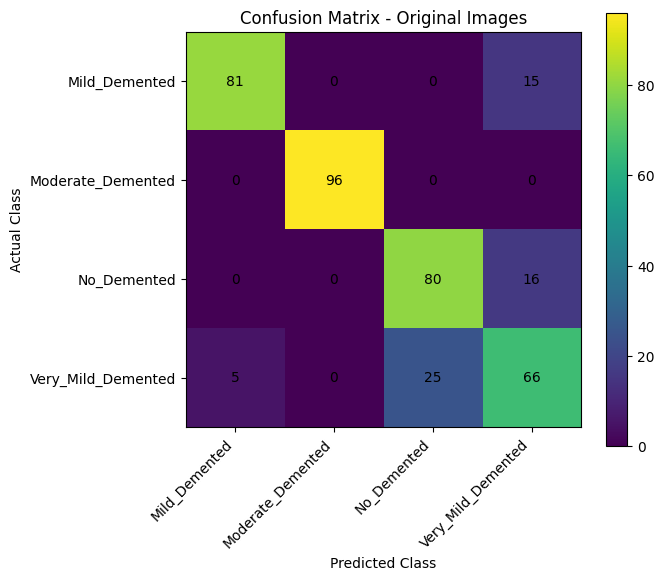

In [ ]:
# ============================================================
# CONFUSION MATRIX - IMAGE
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("\nConfusion Matrix:")
print(cm)


plt.figure(figsize=(7, 6))

plt.imshow(cm, interpolation="nearest")

plt.title("Confusion Matrix - Original Images")
plt.colorbar()

plt.xticks(
    range(NUM_CLASSES),
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(NUM_CLASSES),
    CLASS_NAMES
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

# Write values inside each cell
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    "/content/originalimage_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# EXPERIMENT 2
# CNN TRAINING ON GAN-GENERATED ALZHEIMER MRI IMAGES
#
# Training  : GAN-generated images (480 per class)
# Testing   : ORIGINAL REAL images
#
# IMPORTANT:
# Same CNN architecture + same settings as Experiment 1
# ============================================================

import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


# ============================================================
# 1. SETTINGS
# ============================================================

# GAN generated images
GAN_PATH = "/content/drive/My Drive/GAN_Generated_Images_480"

# Original Alzheimer dataset
REAL_PATH = "/content/drive/My Drive/Alzhiemer_GAN_federated/Alzhiemer's_disease"

CLASS_NAMES = [
    "Mild_Demented",
    "Moderate_Demented",
    "No_Demented",
    "Very_Mild_Demented"
]

NUM_CLASSES = 4
IMAGE_SIZE = 64

BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 0.001

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)


# ============================================================
# 2. LOAD GAN IMAGES
# ============================================================

gan_images = []
gan_labels = []

print("\nLoading GAN-generated images...\n")

for class_index, class_name in enumerate(CLASS_NAMES):

    class_path = os.path.join(
        GAN_PATH,
        class_name
    )

    files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    # Use only 480 images
    files = files[:480]

    print(
        class_name,
        ":",
        len(files),
        "GAN images"
    )

    for file_name in files:

        image_path = os.path.join(
            class_path,
            file_name
        )

        image = Image.open(
            image_path
        ).convert("L")

        image = image.resize(
            (IMAGE_SIZE, IMAGE_SIZE)
        )

        image = np.array(
            image,
            dtype=np.float32
        ) / 255.0

        gan_images.append(image)
        gan_labels.append(class_index)


gan_images = np.array(gan_images)
gan_labels = np.array(gan_labels)

print(
    "\nTotal GAN training images:",
    len(gan_images)
)


# ============================================================
# 3. LOAD REAL IMAGES
#
# These REAL images are used only for testing.
#
# IMPORTANT:
# Ideally, these images should NOT have been used while
# selecting/training the GAN.
# ============================================================

real_images = []
real_labels = []

print("\nLoading real test images...\n")

for class_index, class_name in enumerate(CLASS_NAMES):

    class_path = os.path.join(
        REAL_PATH,
        class_name
    )

    files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    # --------------------------------------------------------
    # Take images AFTER the first 480.
    #
    # This assumes the first 480 images are the real-training
    # pool and the remaining images are available for testing.
    #
    # If you create a fixed separate test folder later,
    # replace this section with that folder.
    # --------------------------------------------------------

    files = files[480:]

    for file_name in files:

        image_path = os.path.join(
            class_path,
            file_name
        )

        image = Image.open(
            image_path
        ).convert("L")

        image = image.resize(
            (IMAGE_SIZE, IMAGE_SIZE)
        )

        image = np.array(
            image,
            dtype=np.float32
        ) / 255.0

        real_images.append(image)
        real_labels.append(class_index)


real_images = np.array(real_images)
real_labels = np.array(real_labels)

print(
    "\nTotal real test images:",
    len(real_images)
)


# ============================================================
# 4. PYTORCH DATASET
# ============================================================

class AlzheimerDataset(Dataset):

    def __init__(
        self,
        images,
        labels
    ):

        self.images = torch.tensor(
            images,
            dtype=torch.float32
        )

        self.labels = torch.tensor(
            labels,
            dtype=torch.long
        )

    def __len__(self):

        return len(self.images)

    def __getitem__(
        self,
        index
    ):

        image = self.images[index]

        # Add channel dimension
        # 64x64 -> 1x64x64
        image = image.unsqueeze(0)

        label = self.labels[index]

        return image, label


# ============================================================
# 5. CREATE DATASETS
# ============================================================

train_dataset = AlzheimerDataset(
    gan_images,
    gan_labels
)

test_dataset = AlzheimerDataset(
    real_images,
    real_labels
)


# ============================================================
# 6. DATA LOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


print("\nGAN training images:",
      len(train_dataset))

print("Real testing images:",
      len(test_dataset))


# ============================================================
# 7. SAME CNN ARCHITECTURE
#
# EXACTLY SAME AS EXPERIMENT 1
# ============================================================

class BasicCNN(nn.Module):

    def __init__(self):

        super(BasicCNN, self).__init__()

        self.features = nn.Sequential(

            # -------------------------
            # Block 1
            # -------------------------

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),


            # -------------------------
            # Block 2
            # -------------------------

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),


            # -------------------------
            # Block 3
            # -------------------------

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )


        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 8 * 8,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(
                128,
                NUM_CLASSES
            )
        )


    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


# ============================================================
# 8. CREATE MODEL
# ============================================================

model = BasicCNN().to(DEVICE)

print("\n========================================")
print("CNN ARCHITECTURE")
print("========================================")

print(model)


# ============================================================
# 9. LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss()


# ============================================================
# 10. OPTIMIZER
# ============================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


# ============================================================
# 11. TRAIN CNN USING GAN IMAGES
# ============================================================

print("\n========================================")
print("TRAINING CNN ON GAN IMAGES")
print("========================================\n")


for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    correct = 0
    total = 0


    for images_batch, labels_batch in train_loader:

        images_batch = images_batch.to(
            DEVICE
        )

        labels_batch = labels_batch.to(
            DEVICE
        )


        # -------------------------
        # Clear old gradients
        # -------------------------

        optimizer.zero_grad()


        # -------------------------
        # Forward pass
        # -------------------------

        outputs = model(
            images_batch
        )


        # -------------------------
        # Calculate loss
        # -------------------------

        loss = criterion(
            outputs,
            labels_batch
        )


        # -------------------------
        # Backpropagation
        # -------------------------

        loss.backward()


        # -------------------------
        # Update weights
        # -------------------------

        optimizer.step()


        # -------------------------
        # Statistics
        # -------------------------

        running_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels_batch.size(0)

        correct += (
            predicted == labels_batch
        ).sum().item()


    train_accuracy = (
        100 * correct / total
    )


    average_loss = (
        running_loss /
        len(train_loader)
    )


    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {average_loss:.4f} "
        f"GAN Train Accuracy: "
        f"{train_accuracy:.2f}%"
    )


# ============================================================
# 12. TEST ON REAL IMAGES
# ============================================================

print("\n========================================")
print("TESTING ON REAL IMAGES")
print("========================================")


model.eval()

all_predictions = []
all_labels = []


with torch.no_grad():

    for images_batch, labels_batch in test_loader:

        images_batch = images_batch.to(
            DEVICE
        )


        outputs = model(
            images_batch
        )


        _, predicted = torch.max(
            outputs,
            1
        )


        all_predictions.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels_batch.numpy()
        )


# ============================================================
# 13. CALCULATE ACCURACY
# ============================================================

accuracy = accuracy_score(
    all_labels,
    all_predictions
)


# ============================================================
# 14. FINAL RESULTS
# ============================================================

print("\n========================================")
print("GAN → REAL RESULTS")
print("========================================")

print(
    f"Real Test Accuracy: "
    f"{accuracy * 100:.2f}%"
)


# ============================================================
# 15. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=CLASS_NAMES,
        digits=4
    )
)


# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

print("\nConfusion Matrix:\n")

print(
    confusion_matrix(
        all_labels,
        all_predictions
    )
)



Device: cuda

Loading GAN-generated images...

Mild_Demented : 480 GAN images
Moderate_Demented : 480 GAN images
No_Demented : 480 GAN images
Very_Mild_Demented : 480 GAN images

Total GAN training images: 1920

Loading real test images...


Total real test images: 8576

GAN training images: 1920
Real testing images: 8576

CNN ARCHITECTURE
BasicCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_feat

Device: cuda

CHECKING PATHS
REAL PATH:
/content/drive/MyDrive/Alzhiemer_GAN_federated/Alzhiemer's_disease
Exists: True

GAN PATH:
/content/drive/MyDrive/GAN_Generated_Images_480
Exists: True

LOADING GAN IMAGES
Mild_Demented: 480 GAN images
Moderate_Demented: 480 GAN images
No_Demented: 480 GAN images
Very_Mild_Demented: 480 GAN images

Total GAN images: 1920

SPLITTING GAN DATA
Mild_Demented: Train = 384, Test = 96
Moderate_Demented: Train = 384, Test = 96
No_Demented: Train = 384, Test = 96
Very_Mild_Demented: Train = 384, Test = 96

GAN TRAINING IMAGES: 1536
GAN TEST IMAGES: 384

LOADING REAL IMAGES
Mild_Demented: 2624 real images
Moderate_Demented: 2624 real images
No_Demented: 2624 real images
Very_Mild_Demented: 2624 real images

CREATING REAL TEST SET
Mild_Demented: Real test = 96
Moderate_Demented: Real test = 96
No_Demented: Real test = 96
Very_Mild_Demented: Real test = 96

TOTAL REAL TEST IMAGES: 384

CNN ARCHITECTURE
BasicCNN(
  (features): Sequential(
    (0): Conv2d(1, 3

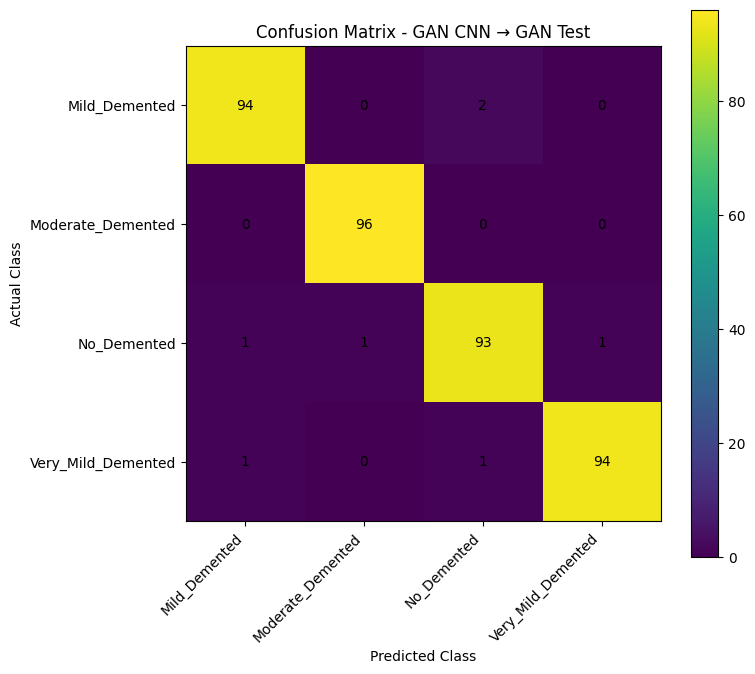

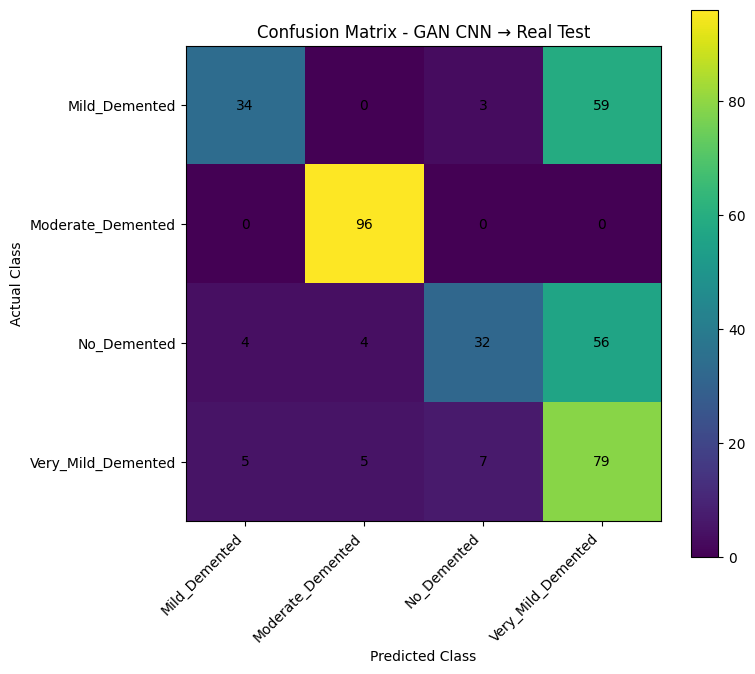



FINAL GAN CNN RESULTS
GAN -> GAN Test Accuracy : 98.18%
GAN -> REAL Test Accuracy: 62.76%

GAN training images      : 1536
GAN test images          : 384
Real test images         : 384

Images per class:
GAN training            : 384
GAN testing             : 96
Real testing            : 96

Saved files:
/content/gan_cnn_model.pth
/content/gan_to_gan_confusion_matrix.png
/content/gan_to_real_confusion_matrix.png


In [ ]:
# ============================================================
# GAN CNN EXPERIMENT
#
# TRAIN:
#   384 GAN images / class
#   = 1536 GAN training images
#
# TEST 1:
#   96 GAN images / class
#   = 384 GAN test images
#
# TEST 2:
#   96 REAL images / class
#   = 384 REAL test images
#
# SAME BASIC CNN ARCHITECTURE
# ============================================================

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from PIL import Image
import matplotlib.pyplot as plt


# ============================================================
# 1. DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)


# ============================================================
# 2. PATHS
# ============================================================

REAL_PATH = (
    "/content/drive/MyDrive/"
    "Alzhiemer_GAN_federated/"
    "Alzhiemer's_disease"
)

GAN_PATH = (
    "/content/drive/MyDrive/"
    "GAN_Generated_Images_480"
)


# ============================================================
# 3. SETTINGS
# ============================================================

CLASS_NAMES = [
    "Mild_Demented",
    "Moderate_Demented",
    "No_Demented",
    "Very_Mild_Demented"
]

NUM_CLASSES = 4

IMG_SIZE = 64

BATCH_SIZE = 16

EPOCHS = 20

LEARNING_RATE = 0.001

SEED = 42


# ============================================================
# 4. RANDOM SEED
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 5. CHECK PATHS
# ============================================================

print("\n========================================")
print("CHECKING PATHS")
print("========================================")

print("REAL PATH:")
print(REAL_PATH)
print("Exists:", os.path.exists(REAL_PATH))

print("\nGAN PATH:")
print(GAN_PATH)
print("Exists:", os.path.exists(GAN_PATH))


if not os.path.exists(REAL_PATH):
    raise FileNotFoundError(
        "Real dataset path not found."
    )

if not os.path.exists(GAN_PATH):
    raise FileNotFoundError(
        "GAN dataset path not found."
    )


# ============================================================
# 6. DATASET CLASS
# ============================================================

class AlzheimerDataset(Dataset):

    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):

        image_path, label = self.samples[index]

        image = Image.open(
            image_path
        ).convert("L")

        image = image.resize(
            (IMG_SIZE, IMG_SIZE)
        )

        image = np.array(
            image,
            dtype=np.float32
        ) / 255.0

        image = torch.tensor(
            image
        ).unsqueeze(0)

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return image, label


# ============================================================
# 7. LOAD GAN IMAGES
# ============================================================

gan_samples = []

print("\n========================================")
print("LOADING GAN IMAGES")
print("========================================")

for label, class_name in enumerate(CLASS_NAMES):

    class_path = os.path.join(
        GAN_PATH,
        class_name
    )

    if not os.path.exists(class_path):
        raise FileNotFoundError(
            f"GAN class folder not found: {class_path}"
        )

    files = [
        os.path.join(class_path, f)
        for f in os.listdir(class_path)
        if f.lower().endswith(
            (".png", ".jpg", ".jpeg", ".bmp")
        )
    ]

    files = sorted(files)

    # EXACTLY 480 GAN IMAGES / CLASS
    if len(files) < 480:
        raise ValueError(
            f"{class_name} has only "
            f"{len(files)} GAN images. "
            f"Need at least 480."
        )

    files = files[:480]

    print(
        f"{class_name}: {len(files)} GAN images"
    )

    for file in files:
        gan_samples.append(
            (file, label)
        )


print(
    "\nTotal GAN images:",
    len(gan_samples)
)


# ============================================================
# 8. SPLIT GAN DATA
#
# 480/class
#
# 80% = 384/class -> TRAIN
# 20% = 96/class  -> TEST
# ============================================================

gan_train_samples = []

gan_test_samples = []

print("\n========================================")
print("SPLITTING GAN DATA")
print("========================================")

for label, class_name in enumerate(CLASS_NAMES):

    class_samples = [
        sample
        for sample in gan_samples
        if sample[1] == label
    ]

    train_part, test_part = train_test_split(
        class_samples,
        test_size=0.20,
        random_state=SEED,
        shuffle=True
    )

    gan_train_samples.extend(
        train_part
    )

    gan_test_samples.extend(
        test_part
    )

    print(
        f"{class_name}: "
        f"Train = {len(train_part)}, "
        f"Test = {len(test_part)}"
    )


print("\nGAN TRAINING IMAGES:",
      len(gan_train_samples))

print("GAN TEST IMAGES:",
      len(gan_test_samples))


# ============================================================
# 9. LOAD REAL IMAGES
# ============================================================

real_samples = []

print("\n========================================")
print("LOADING REAL IMAGES")
print("========================================")

for label, class_name in enumerate(CLASS_NAMES):

    class_path = os.path.join(
        REAL_PATH,
        class_name
    )

    if not os.path.exists(class_path):
        raise FileNotFoundError(
            f"Real class folder not found: {class_path}"
        )

    files = [
        os.path.join(class_path, f)
        for f in os.listdir(class_path)
        if f.lower().endswith(
            (".png", ".jpg", ".jpeg", ".bmp")
        )
    ]

    print(
        f"{class_name}: {len(files)} real images"
    )

    for file in files:

        real_samples.append(
            (file, label)
        )


# ============================================================
# 10. CREATE REAL TEST SET
#
# EXACTLY 96 REAL IMAGES / CLASS
# TOTAL = 384 REAL TEST IMAGES
#
# We first select 480/class, then take 20%.
# ============================================================

real_test_samples = []

print("\n========================================")
print("CREATING REAL TEST SET")
print("========================================")

for label, class_name in enumerate(CLASS_NAMES):

    class_samples = [
        sample
        for sample in real_samples
        if sample[1] == label
    ]

    # Shuffle using fixed seed
    random.seed(SEED + label)
    random.shuffle(class_samples)

    # Select 480 real images/class
    class_samples = class_samples[:480]

    # Take 20% = 96
    _, test_part = train_test_split(
        class_samples,
        test_size=0.20,
        random_state=SEED,
        shuffle=True
    )

    real_test_samples.extend(
        test_part
    )

    print(
        f"{class_name}: "
        f"Real test = {len(test_part)}"
    )


print(
    "\nTOTAL REAL TEST IMAGES:",
    len(real_test_samples)
)


# ============================================================
# 11. CREATE DATASETS
# ============================================================

gan_train_dataset = AlzheimerDataset(
    gan_train_samples
)

gan_test_dataset = AlzheimerDataset(
    gan_test_samples
)

real_test_dataset = AlzheimerDataset(
    real_test_samples
)


# ============================================================
# 12. DATA LOADERS
# ============================================================

gan_train_loader = DataLoader(
    gan_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

gan_test_loader = DataLoader(
    gan_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

real_test_loader = DataLoader(
    real_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# 13. BASIC CNN
# SAME ARCHITECTURE AS ORIGINAL CNN
# ============================================================

class BasicCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 8 * 8,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(
                128,
                NUM_CLASSES
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


# ============================================================
# 14. CREATE GAN CNN
# ============================================================

model = BasicCNN().to(DEVICE)

print("\n========================================")
print("CNN ARCHITECTURE")
print("========================================")

print(model)


# ============================================================
# 15. TRAIN ONLY ON GAN IMAGES
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


print("\n========================================")
print("TRAINING CNN ON GAN IMAGES")
print("========================================")

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    correct = 0

    total = 0

    for images, labels in gan_train_loader:

        images = images.to(DEVICE)

        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    train_accuracy = (
        100 * correct / total
    )

    avg_loss = (
        running_loss / len(gan_train_loader)
    )

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {avg_loss:.4f} "
        f"GAN Train Accuracy: "
        f"{train_accuracy:.2f}%"
    )


# ============================================================
# 16. SAVE GAN CNN
# ============================================================

torch.save(
    model.state_dict(),
    "/content/gan_cnn_model.pth"
)

print(
    "\nGAN CNN saved to:"
)

print(
    "/content/gan_cnn_model.pth"
)


# ============================================================
# 17. EVALUATION FUNCTION
# ============================================================

def evaluate(
    model,
    loader,
    title
):

    model.eval()

    all_labels = []

    all_predictions = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE)

            outputs = model(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            all_labels.extend(
                labels.numpy()
            )

            all_predictions.extend(
                predicted.cpu().numpy()
            )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    cm = confusion_matrix(
        all_labels,
        all_predictions
    )

    print("\n========================================")
    print(title)
    print("========================================")

    print(
        f"Accuracy: {accuracy * 100:.2f}%"
    )

    print("\nClassification Report:")

    print(
        classification_report(
            all_labels,
            all_predictions,
            target_names=CLASS_NAMES,
            digits=4
        )
    )

    print("\nConfusion Matrix:")

    print(cm)

    return accuracy, cm


# ============================================================
# 18. TEST 1:
# GAN CNN -> UNSEEN GAN IMAGES
#
# 96/class = 384 total
# ============================================================

gan_accuracy, gan_cm = evaluate(
    model,
    gan_test_loader,
    "GAN CNN -> UNSEEN GAN TEST IMAGES"
)


# ============================================================
# 19. TEST 2:
# GAN CNN -> REAL IMAGES
#
# 96/class = 384 total
# ============================================================

real_accuracy, real_cm = evaluate(
    model,
    real_test_loader,
    "GAN CNN -> REAL TEST IMAGES"
)


# ============================================================
# 20. CONFUSION MATRIX - GAN TEST
# ============================================================

plt.figure(figsize=(8, 7))

plt.imshow(
    gan_cm,
    interpolation="nearest"
)

plt.title(
    "Confusion Matrix - GAN CNN → GAN Test"
)

plt.colorbar()

plt.xticks(
    range(NUM_CLASSES),
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(NUM_CLASSES),
    CLASS_NAMES
)

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        plt.text(
            j,
            i,
            gan_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    "/content/gan_to_gan_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 21. CONFUSION MATRIX - REAL TEST
# ============================================================

plt.figure(figsize=(8, 7))

plt.imshow(
    real_cm,
    interpolation="nearest"
)

plt.title(
    "Confusion Matrix - GAN CNN → Real Test"
)

plt.colorbar()

plt.xticks(
    range(NUM_CLASSES),
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(NUM_CLASSES),
    CLASS_NAMES
)

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        plt.text(
            j,
            i,
            real_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    "/content/gan_to_real_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 22. FINAL RESULTS
# ============================================================

print("\n")
print("================================================")
print("FINAL GAN CNN RESULTS")
print("================================================")

print(
    f"GAN -> GAN Test Accuracy : "
    f"{gan_accuracy * 100:.2f}%"
)

print(
    f"GAN -> REAL Test Accuracy: "
    f"{real_accuracy * 100:.2f}%"
)

print("\nGAN training images      :", len(gan_train_samples))
print("GAN test images          :", len(gan_test_samples))
print("Real test images         :", len(real_test_samples))

print("\nImages per class:")
print("GAN training            : 384")
print("GAN testing             : 96")
print("Real testing            : 96")

print("\nSaved files:")

print("/content/gan_cnn_model.pth")

print("/content/gan_to_gan_confusion_matrix.png")

print("/content/gan_to_real_confusion_matrix.png")

print("================================================")

Mounted at /content/drive
Device: cpu

SELECTING REAL IMAGES (480 train / 96 test per class)
  Mild_Demented: 480 real train (copied to Real_480_Selected), 96 real test
  Moderate_Demented: 480 real train (copied to Real_480_Selected), 96 real test
  No_Demented: 480 real train (copied to Real_480_Selected), 96 real test
  Very_Mild_Demented: 480 real train (copied to Real_480_Selected), 96 real test

✅ Real images copied to: /content/drive/MyDrive/Real_480_Selected

LOADING GAN IMAGES
  Mild_Demented: 480 GAN images
  Moderate_Demented: 480 GAN images
  No_Demented: 480 GAN images
  Very_Mild_Demented: 480 GAN images

📊 Combined training set: 3840 images (480 real + 480 GAN per class)
📊 Real test set: 384 images (96 per class)

CNN architecture:
BasicCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_si

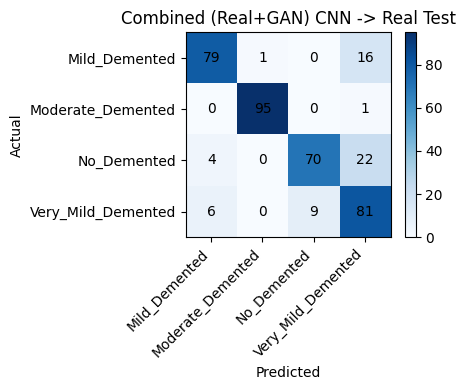


COMPARISON SUMMARY (fill in your previous numbers)
Real-only baseline  -> Real test  : 84.11%  (your earlier run)
GAN-only            -> Real test  : 62.76%  (your earlier run)
Real+GAN combined   -> Real test  : 84.64%  (this run)


In [ ]:
# ============================================
# AUGMENTED CNN: 480 REAL + 480 GAN per class, tested on REAL test set
# Matches your existing BasicCNN architecture and folder structure.
# ============================================

from google.colab import drive
drive.mount('/content/drive')

import os
import random
import shutil
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

class_names = ['Mild_Demented', 'Moderate_Demented', 'No_Demented', 'Very_Mild_Demented']

REAL_PATH = "/content/drive/MyDrive/Alzhiemer_GAN_federated/Alzhiemer's_disease"
GAN_PATH = "/content/drive/MyDrive/GAN_Generated_Images_480"
REAL_SELECTED_PATH = "/content/drive/MyDrive/Real_480_Selected"  # new folder, real images only

REAL_TRAIN_PER_CLASS = 480   # real images used for the combined training set
GAN_TRAIN_PER_CLASS = 480    # GAN images used for the combined training set
REAL_TEST_PER_CLASS = 96     # held-out real test set (not used in training)

IMG_SIZE = 64

# ============================================
# STEP 1: SELECT 480 REAL TRAIN + 96 REAL TEST PER CLASS (non-overlapping)
# and copy the 480 train ones into their own folder
# ============================================

print("\n" + "=" * 60)
print("SELECTING REAL IMAGES (480 train / 96 test per class)")
print("=" * 60)

def list_images(folder):
    return sorted([f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

real_train_paths, real_train_labels = [], []
real_test_paths, real_test_labels = [], []

os.makedirs(REAL_SELECTED_PATH, exist_ok=True)

for label, cname in enumerate(class_names):
    class_dir = os.path.join(REAL_PATH, cname)
    files = list_images(class_dir)
    random.Random(42).shuffle(files)  # fixed seed -> reproducible selection

    train_files = files[:REAL_TRAIN_PER_CLASS]
    test_files = files[REAL_TRAIN_PER_CLASS:REAL_TRAIN_PER_CLASS + REAL_TEST_PER_CLASS]

    out_class_dir = os.path.join(REAL_SELECTED_PATH, cname)
    os.makedirs(out_class_dir, exist_ok=True)

    for f in train_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(out_class_dir, f)
        if not os.path.exists(dst):
            shutil.copy(src, dst)
        real_train_paths.append(src)
        real_train_labels.append(label)

    for f in test_files:
        real_test_paths.append(os.path.join(class_dir, f))
        real_test_labels.append(label)

    print(f"  {cname}: {len(train_files)} real train (copied to Real_480_Selected), "
          f"{len(test_files)} real test")

print(f"\n✅ Real images copied to: {REAL_SELECTED_PATH}")

# ============================================
# STEP 2: LOAD GAN IMAGES (480 per class, already generated)
# ============================================

print("\n" + "=" * 60)
print("LOADING GAN IMAGES")
print("=" * 60)

gan_train_paths, gan_train_labels = [], []
for label, cname in enumerate(class_names):
    class_dir = os.path.join(GAN_PATH, cname)
    files = list_images(class_dir)[:GAN_TRAIN_PER_CLASS]
    for f in files:
        gan_train_paths.append(os.path.join(class_dir, f))
        gan_train_labels.append(label)
    print(f"  {cname}: {len(files)} GAN images")

# ============================================
# STEP 3: COMBINE REAL + GAN FOR TRAINING
# ============================================

combined_train_paths = real_train_paths + gan_train_paths
combined_train_labels = real_train_labels + gan_train_labels

print(f"\n📊 Combined training set: {len(combined_train_paths)} images "
      f"({REAL_TRAIN_PER_CLASS} real + {GAN_TRAIN_PER_CLASS} GAN per class)")
print(f"📊 Real test set: {len(real_test_paths)} images ({REAL_TEST_PER_CLASS} per class)")

# ============================================
# STEP 4: DATASET + DATALOADERS
# ============================================

class MRIDataset(Dataset):
    def __init__(self, image_paths, labels):
        self.image_paths = image_paths
        self.labels = labels

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('L').resize((IMG_SIZE, IMG_SIZE))
        img = np.array(img, dtype=np.float32) / 255.0
        img = (img - 0.5) / 0.5
        img = torch.from_numpy(img).unsqueeze(0)
        return img, self.labels[idx]

BATCH_SIZE = 32

train_dataset = MRIDataset(combined_train_paths, combined_train_labels)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = MRIDataset(real_test_paths, real_test_labels)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ============================================
# STEP 5: CNN ARCHITECTURE (same BasicCNN as your existing runs)
# ============================================

class BasicCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(BasicCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8192, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BasicCNN(num_classes=4).to(device)
print("\nCNN architecture:")
print(model)

# ============================================
# STEP 6: TRAINING
# ============================================

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
EPOCHS = 20

print("\n" + "=" * 60)
print("TRAINING CNN ON COMBINED (REAL + GAN) IMAGES")
print("=" * 60)

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total * 100
    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {epoch_loss:.4f} Train Accuracy: {epoch_acc:.2f}%")

torch.save(model.state_dict(), '/content/combined_cnn_model.pth')
print("\n✅ Combined CNN saved to: /content/combined_cnn_model.pth")

# ============================================
# STEP 7: EVALUATE ON REAL TEST SET
# ============================================

print("\n" + "=" * 60)
print("COMBINED CNN -> REAL TEST IMAGES")
print("=" * 60)

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"Accuracy: {acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Combined (Real+GAN) CNN -> Real Test')
plt.colorbar()
plt.xticks(range(4), class_names, rotation=45, ha='right')
plt.yticks(range(4), class_names)
for i in range(4):
    for j in range(4):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('/content/combined_to_real_confusion_matrix.png', dpi=150)
plt.show()

# ============================================
# FINAL SUMMARY — compare against your previous runs
# ============================================

print("\n" + "=" * 60)
print("COMPARISON SUMMARY (fill in your previous numbers)")
print("=" * 60)
print(f"Real-only baseline  -> Real test  : 84.11%  (your earlier run)")
print(f"GAN-only            -> Real test  : 62.76%  (your earlier run)")
print(f"Real+GAN combined   -> Real test  : {acc*100:.2f}%  (this run)")
print("=" * 60)

In [ ]:
import os

print("Checking /content/checkpoints_stable ...")

if os.path.exists("/content/checkpoints_stable"):
    print(
        os.listdir("/content/checkpoints_stable")
    )
else:
    print("❌ checkpoints_stable folder not found")


print("\nChecking Drive ...")

for root, dirs, files in os.walk(
    "/content/drive/MyDrive"
):
    for file in files:
        if file.endswith(".pth"):
            print(
                os.path.join(root, file)
            )

Checking /content/checkpoints_stable ...
❌ checkpoints_stable folder not found

Checking Drive ...
/content/drive/MyDrive/sheep_model/best_model.pth
/content/drive/MyDrive/sheep_folder_swintransformer/best_model.pth
/content/drive/MyDrive/sheep_folder_swintransformer/best_cow_model.pth
/content/drive/MyDrive/sheep_folder_swintransformer/best_swin_cbam.pth
/content/drive/MyDrive/sheep_folder_swintransformer/best_swin_small_cbam.pth
/content/drive/MyDrive/sheep_folder_swintransformer/best_clean_cbam.pth
/content/drive/MyDrive/sheep_folder_swintransformer/best_buffalo_finetuned.pth
/content/drive/MyDrive/sheep_folder_swintransformer/buffalo_final_90.pth
/content/drive/MyDrive/sheep_folder_swintransformer/buffalo_checkpoints/checkpoint_latest.pth
/content/drive/MyDrive/sheep_folder_swintransformer/buffalo_checkpoints/best_model.pth
/content/drive/MyDrive/sheep_folder_swintransformer/buffalo_checkpoints/phase3_retry_best.pth
/content/drive/MyDrive/sheep_folder_swintransformer/buffalo_checkp

Mounted at /content/drive
✅ Using device: cuda
📂 Dataset path: /content/drive/My Drive/Alzhiemer_GAN_federated/Alzhiemer's_disease

📂 Loading dataset...
  ✅ Mild_Demented: 2624 images
  ✅ Moderate_Demented: 2624 images
  ✅ No_Demented: 2624 images
  ✅ Very_Mild_Demented: 2624 images

📊 Total images: 10496

📊 Split complete:
   Train: 7344 images
   Test: 3152 images
   Train batches: 114
   Test batches: 50

🚀 STARTING FIXED GAN TRAINING

FIXED WGAN-GP TRAINING - 64x64 IMAGES
Device: cuda
Epochs: 20
Batch size: 64
Learning Rate: 0.0001
n_critic: 5
lambda_gp: 10



Epoch 1/20: 100%|██████████| 114/114 [1:11:25<00:00, 37.59s/it, G=28.6593, C=-19.1974]


Epoch [1/20] - G_loss: 30.1532, C_loss: -37.8731


Epoch 2/20: 100%|██████████| 114/114 [01:34<00:00,  1.21it/s, G=26.3260, C=-12.0306]


Epoch [2/20] - G_loss: 33.9240, C_loss: -14.6750


...

Epoch [18/20] - G_loss: -9.4311, C_loss: -8.1809


Epoch 19/20: 100%|██████████| 114/114 [01:10<00:00,  1.62it/s, G=-11.4268, C=-7.5871]


Epoch [19/20] - G_loss: -11.2879, C_loss: -8.0761


Epoch 20/20: 100%|██████████| 114/114 [01:10<00:00,  1.62it/s, G=-13.7450, C=-6.5317]


Epoch [20/20] - G_loss: -12.9812, C_loss: -8.0435
✅ Model saved at /content/drive/My Drive/Alzhiemer_GAN_federated/checkpoints_stable/wgan_gp_epoch_20.pth
✅ Model saved at /content/drive/My Drive/Alzhiemer_GAN_federated/checkpoints_stable/wgan_gp_epoch_20.pth


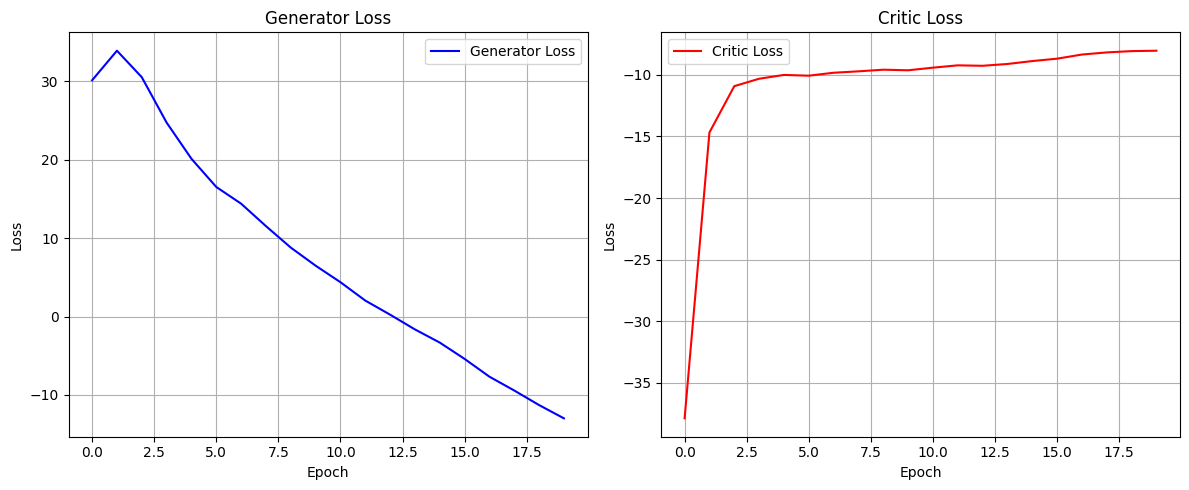


✅ GAN Training Complete!

📸 GENERATING SYNTHETIC IMAGES
  ✅ Mild_Demented: Saved 20 generated images
  ✅ Moderate_Demented: Saved 20 generated images
  ✅ No_Demented: Saved 20 generated images
  ✅ Very_Mild_Demented: Saved 20 generated images

✅ Generated images saved to: /content/drive/My Drive/GAN_Generated_Images_Stable

👁️  VISUALIZING REAL VS GENERATED


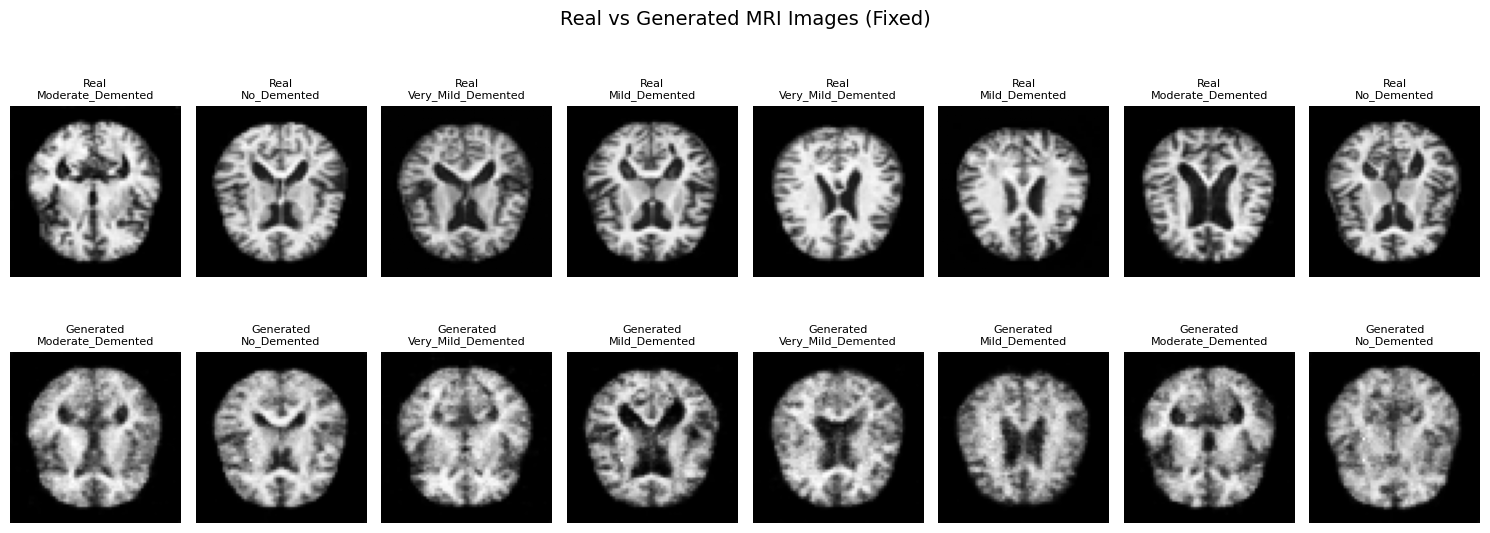


🎉 TRAINING COMPLETE!


In [ ]:
# ============================================
# FIXED WGAN-GP (BatchNorm -> GroupNorm in critic)
# ============================================
#
# ROOT CAUSE OF THE EXPLODING LOSSES:
# The critic used nn.BatchNorm2d. WGAN-GP's gradient penalty requires the
# critic's output for a given (interpolated) sample to depend ONLY on that
# sample. BatchNorm violates this because it normalizes using the batch's
# mean/variance, so gradients leak across samples in the batch. That makes
# the gradient-penalty estimate wrong, and the critic and generator losses
# feed off each other and diverge (which is exactly the G=18 -> 2700,
# C=-25 -> -5400 spiral you saw by epoch 6-7).
#
# Fix: use GroupNorm (or InstanceNorm) in the critic instead — both
# normalize per-sample, per-channel, so they don't break the GP assumption.
# BatchNorm in the GENERATOR is fine and was left unchanged.

from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")

# ============================================
# YOUR DATASET PATH
# ============================================

DATA_PATH = "/content/drive/My Drive/Alzhiemer_GAN_federated/Alzhiemer's_disease"
class_names = ['Mild_Demented', 'Moderate_Demented', 'No_Demented', 'Very_Mild_Demented']

print(f"📂 Dataset path: {DATA_PATH}")

# ============================================
# LOAD DATASET (unchanged)
# ============================================

class MRIDataset(Dataset):
    def __init__(self, image_paths, labels):
        self.image_paths = image_paths
        self.labels = labels

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        try:
            img = Image.open(img_path).convert('L')
            img = img.resize((64, 64))
            img = np.array(img, dtype=np.float32)
            img = (img / 127.5) - 1
            img = torch.from_numpy(img).unsqueeze(0)
        except Exception:
            img = torch.zeros(1, 64, 64)

        return img, label

def load_mri_data(data_dir):
    all_paths = []
    all_labels = []

    print("\n📂 Loading dataset...")

    for label, class_name in enumerate(class_names):
        class_dir = os.path.join(data_dir, class_name)
        if os.path.exists(class_dir):
            files = [f for f in os.listdir(class_dir)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            for img_file in files:
                all_paths.append(os.path.join(class_dir, img_file))
                all_labels.append(label)
            print(f"  ✅ {class_name}: {len(files)} images")

    print(f"\n📊 Total images: {len(all_paths)}")
    return all_paths, all_labels

def train_test_split(paths, labels, train_ratio=0.7):
    class_indices = {i: [] for i in range(4)}
    for idx, label in enumerate(labels):
        class_indices[label].append(idx)

    train_indices = []
    test_indices = []

    for label, indices in class_indices.items():
        np.random.shuffle(indices)
        split_point = int(len(indices) * train_ratio)
        train_indices.extend(indices[:split_point])
        test_indices.extend(indices[split_point:])

    train_paths = [paths[i] for i in train_indices]
    train_labels = [labels[i] for i in train_indices]
    test_paths = [paths[i] for i in test_indices]
    test_labels = [labels[i] for i in test_indices]

    return train_paths, train_labels, test_paths, test_labels

all_paths, all_labels = load_mri_data(DATA_PATH)

train_paths, train_labels, test_paths, test_labels = train_test_split(
    all_paths, all_labels, train_ratio=0.7
)

print(f"\n📊 Split complete:")
print(f"   Train: {len(train_paths)} images")
print(f"   Test: {len(test_paths)} images")

train_dataset = MRIDataset(train_paths, train_labels)
test_dataset = MRIDataset(test_paths, test_labels)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"   Train batches: {len(train_loader)}")
print(f"   Test batches: {len(test_loader)}")

# ============================================
# GENERATOR (unchanged — BatchNorm here is fine)
# ============================================

class SimpleGenerator(nn.Module):
    def __init__(self, latent_dim=100, num_classes=4):
        super(SimpleGenerator, self).__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        self.label_embedding = nn.Embedding(num_classes, latent_dim)
        self.fc = nn.Linear(latent_dim * 2, 256 * 4 * 4)

        self.main = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.ConvTranspose2d(32, 1, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z, labels):
        label_emb = self.label_embedding(labels)
        z = torch.cat([z, label_emb], dim=1)
        out = self.fc(z)
        out = out.view(out.size(0), 256, 4, 4)
        img = self.main(out)
        return img

# ============================================
# CRITIC — FIXED: BatchNorm2d -> GroupNorm, Dropout removed
# ============================================

class SimpleCritic(nn.Module):
    def __init__(self, num_classes=4, img_size=64):
        super(SimpleCritic, self).__init__()
        self.num_classes = num_classes
        self.img_size = img_size

        self.label_embedding = nn.Embedding(num_classes, img_size * img_size)

        # GroupNorm normalizes per-sample (splits channels into groups and
        # normalizes within each sample), unlike BatchNorm which normalizes
        # across the batch. This keeps the gradient penalty's per-sample
        # assumption valid. No norm on the first layer (standard WGAN-GP
        # practice, same reason DCGAN skips BN on the first D layer).
        self.main = nn.Sequential(
            nn.Conv2d(2, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.GroupNorm(8, 128),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.GroupNorm(8, 256),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.GroupNorm(8, 512),
            nn.LeakyReLU(0.2, True),
        )
        self.fc = nn.Linear(512 * 4 * 4, 1)

    def forward(self, img, labels):
        label_emb = self.label_embedding(labels)
        label_emb = label_emb.view(label_emb.size(0), 1, self.img_size, self.img_size)
        d_in = torch.cat([img, label_emb], dim=1)
        out = self.main(d_in)
        out = out.view(out.size(0), -1)
        score = self.fc(out)
        return score

# ============================================
# WGAN-GP TRAINER — lr tuned back to spec, gradient clipping,
# and a divergence guard so it stops itself instead of hanging forever
# ============================================

class StableWGAN_GP:
    def __init__(self, latent_dim=100, num_classes=4, lambda_gp=10, n_critic=5,
                 lr_g=0.0001, lr_c=0.0001, device=None, loss_explode_threshold=200.0):
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.lambda_gp = lambda_gp
        self.n_critic = n_critic
        self.device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.loss_explode_threshold = loss_explode_threshold

        self.generator = SimpleGenerator(latent_dim, num_classes).to(self.device)
        self.critic = SimpleCritic(num_classes).to(self.device)

        self.optimizer_G = optim.Adam(self.generator.parameters(), lr=lr_g, betas=(0.5, 0.9))
        self.optimizer_C = optim.Adam(self.critic.parameters(), lr=lr_c, betas=(0.5, 0.9))

        self.g_losses = []
        self.c_losses = []

    def compute_gradient_penalty(self, real_imgs, fake_imgs, labels):
        batch_size = real_imgs.size(0)
        alpha = torch.rand(batch_size, 1, 1, 1).to(self.device)
        alpha = alpha.expand_as(real_imgs)

        interpolated = alpha * real_imgs + (1 - alpha) * fake_imgs
        interpolated.requires_grad_(True)

        critic_interpolated = self.critic(interpolated, labels)

        grad = torch.autograd.grad(
            outputs=critic_interpolated,
            inputs=interpolated,
            grad_outputs=torch.ones_like(critic_interpolated),
            create_graph=True,
            retain_graph=True,
        )[0]

        grad_norm = grad.view(batch_size, -1).norm(2, dim=1)
        gradient_penalty = ((grad_norm - 1) ** 2).mean()
        return gradient_penalty

    def train_step(self, real_imgs, labels):
        batch_size = real_imgs.size(0)

        for _ in range(self.n_critic):
            self.optimizer_C.zero_grad()
            z = torch.randn(batch_size, self.latent_dim).to(self.device)
            fake_imgs = self.generator(z, labels)

            real_score = self.critic(real_imgs, labels)
            fake_score = self.critic(fake_imgs.detach(), labels)
            gradient_penalty = self.compute_gradient_penalty(real_imgs, fake_imgs, labels)

            critic_loss = fake_score.mean() - real_score.mean() + self.lambda_gp * gradient_penalty
            critic_loss.backward()
            # gradient clipping: extra safety net against spikes
            torch.nn.utils.clip_grad_norm_(self.critic.parameters(), max_norm=10.0)
            self.optimizer_C.step()

        self.optimizer_G.zero_grad()
        z = torch.randn(batch_size, self.latent_dim).to(self.device)
        fake_imgs = self.generator(z, labels)
        gen_loss = -self.critic(fake_imgs, labels).mean()
        gen_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.generator.parameters(), max_norm=10.0)
        self.optimizer_G.step()

        return gen_loss.item(), critic_loss.item()

    def train(self, dataloader, epochs=30, save_interval=5):
        print(f"\n{'='*60}")
        print(f"FIXED WGAN-GP TRAINING - 64x64 IMAGES")
        print(f"{'='*60}")
        print(f"Device: {self.device}")
        print(f"Epochs: {epochs}")
        print(f"Batch size: {dataloader.batch_size}")
        print(f"Learning Rate: {self.optimizer_G.param_groups[0]['lr']}")
        print(f"n_critic: {self.n_critic}")
        print(f"lambda_gp: {self.lambda_gp}")
        print(f"{'='*60}\n")

        for epoch in range(epochs):
            epoch_g_loss = 0
            epoch_c_loss = 0
            num_batches = 0

            progress_bar = tqdm(dataloader, desc=f'Epoch {epoch+1}/{epochs}')
            for batch_idx, (imgs, labels) in enumerate(progress_bar):
                imgs = imgs.to(self.device)
                labels = labels.to(self.device)

                g_loss, c_loss = self.train_step(imgs, labels)

                # Divergence guard: stop immediately instead of burning
                # GPU hours on a training run that's already blown up.
                if abs(g_loss) > self.loss_explode_threshold or abs(c_loss) > self.loss_explode_threshold:
                    print(f"\n⚠️  Loss exploded (G={g_loss:.2f}, C={c_loss:.2f}) "
                          f"at epoch {epoch+1}, batch {batch_idx+1}. Stopping early.")
                    print("If this triggers again after the BatchNorm->GroupNorm fix, "
                          "try lowering lr_g/lr_c further (e.g. 0.00005) or lambda_gp.")
                    self.save_model(epoch + 1, save_dir='/content/drive/My Drive/Alzhiemer_GAN_federated/checkpoints_stable_diverged')
                    self.plot_losses()
                    return self.g_losses, self.c_losses

                epoch_g_loss += g_loss
                epoch_c_loss += c_loss
                num_batches += 1

                progress_bar.set_postfix({'G': f'{g_loss:.4f}', 'C': f'{c_loss:.4f}'})

            avg_g_loss = epoch_g_loss / num_batches
            avg_c_loss = epoch_c_loss / num_batches
            self.g_losses.append(avg_g_loss)
            self.c_losses.append(avg_c_loss)

            print(f'Epoch [{epoch+1}/{epochs}] - G_loss: {avg_g_loss:.4f}, C_loss: {avg_c_loss:.4f}')

            if (epoch + 1) % save_interval == 0:
                self.save_samples(epoch + 1)
                self.save_model(epoch + 1)

        self.save_samples(epochs)
        self.save_model(epochs)
        self.plot_losses()

        return self.g_losses, self.c_losses

    def generate_images(self, labels, num_images_per_class=10):
        self.generator.eval()
        generated_images = []

        with torch.no_grad():
            for label in range(self.num_classes):
                label_tensor = torch.full((num_images_per_class,), label, dtype=torch.long).to(self.device)
                z = torch.randn(num_images_per_class, self.latent_dim).to(self.device)
                fake_imgs = self.generator(z, label_tensor)
                generated_images.append(fake_imgs)

        return torch.cat(generated_images, dim=0)

    def save_samples(self, epoch, save_dir='gan_samples_stable'):
        os.makedirs(save_dir, exist_ok=True)

        self.generator.eval()
        fig, axes = plt.subplots(4, 4, figsize=(12, 12))

        with torch.no_grad():
            for label in range(self.num_classes):
                labels = torch.full((4,), label, dtype=torch.long).to(self.device)
                z = torch.randn(4, self.latent_dim).to(self.device)
                imgs = self.generator(z, labels)

                for j in range(4):
                    img = imgs[j].cpu().numpy().squeeze()
                    img = (img + 1) / 2
                    axes[label, j].imshow(img, cmap='gray')
                    axes[label, j].axis('off')
                    if j == 0:
                        axes[label, j].set_ylabel(class_names[label], fontsize=10)

        plt.suptitle(f'Generated Samples - Epoch {epoch}', fontsize=14)
        plt.tight_layout()
        plt.savefig(f'{save_dir}/samples_epoch_{epoch}.png', dpi=150)
        plt.close()
        self.generator.train()

    def save_model(self, epoch, save_dir='/content/drive/My Drive/Alzhiemer_GAN_federated/checkpoints_stable'):
        os.makedirs(save_dir, exist_ok=True)
        torch.save({
            'generator_state_dict': self.generator.state_dict(),
            'critic_state_dict': self.critic.state_dict(),
            'optimizer_G_state_dict': self.optimizer_G.state_dict(),
            'optimizer_C_state_dict': self.optimizer_C.state_dict(),
            'epoch': epoch,
            'g_losses': self.g_losses,
            'c_losses': self.c_losses,
        }, f'{save_dir}/wgan_gp_epoch_{epoch}.pth')
        print(f"✅ Model saved at {save_dir}/wgan_gp_epoch_{epoch}.pth")

    def plot_losses(self):
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(self.g_losses, label='Generator Loss', color='blue')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Generator Loss')
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(self.c_losses, label='Critic Loss', color='red')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Critic Loss')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.savefig('training_losses_stable.png', dpi=150)
        plt.show()

# ============================================
# TRAIN
# ============================================

print("\n" + "="*60)
print("🚀 STARTING FIXED GAN TRAINING")
print("="*60)

trainer = StableWGAN_GP(
    latent_dim=100,
    num_classes=4,
    lambda_gp=10,
    n_critic=5,
    lr_g=0.0001,   # lowered from 0.0002 per WGAN-GP paper recommendation
    lr_c=0.0001,
    device=device
)

EPOCHS = 20
g_losses, c_losses = trainer.train(train_loader, epochs=EPOCHS, save_interval=5)

print("\n✅ GAN Training Complete!")

# ============================================
# GENERATE AND SAVE IMAGES
# ============================================

print("\n" + "="*60)
print("📸 GENERATING SYNTHETIC IMAGES")
print("="*60)

num_per_class = 20
synthetic_images = trainer.generate_images(labels=torch.arange(4), num_images_per_class=num_per_class)

output_dir = '/content/drive/My Drive/GAN_Generated_Images_Stable'
os.makedirs(output_dir, exist_ok=True)

for label in range(4):
    class_dir = os.path.join(output_dir, class_names[label])
    os.makedirs(class_dir, exist_ok=True)

    start_idx = label * num_per_class
    end_idx = start_idx + num_per_class
    class_images = synthetic_images[start_idx:end_idx]

    for i, img_tensor in enumerate(class_images):
        img_np = img_tensor.cpu().numpy().squeeze()
        img_np = (img_np + 1) / 2 * 255
        img_np = img_np.astype(np.uint8)

        img = Image.fromarray(img_np, mode='L')
        img.save(os.path.join(class_dir, f'generated_{i+1}.png'))

    print(f"  ✅ {class_names[label]}: Saved {num_per_class} generated images")

print(f"\n✅ Generated images saved to: {output_dir}")

# ============================================
# VISUALIZE RESULTS
# ============================================

print("\n" + "="*60)
print("👁️  VISUALIZING REAL VS GENERATED")
print("="*60)

def visualize_real_vs_generated(train_loader, trainer, num_samples=8):
    real_imgs, real_labels = next(iter(train_loader))
    real_imgs = real_imgs[:num_samples]
    real_labels = real_labels[:num_samples]

    z = torch.randn(num_samples, trainer.latent_dim).to(trainer.device)
    labels = real_labels.to(trainer.device)
    trainer.generator.eval()
    with torch.no_grad():
        fake_imgs = trainer.generator(z, labels)
    trainer.generator.train()

    fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))

    for i in range(num_samples):
        real = real_imgs[i].cpu().numpy().squeeze()
        real = (real + 1) / 2
        axes[0, i].imshow(real, cmap='gray')
        axes[0, i].set_title(f'Real\n{class_names[real_labels[i].item()]}', fontsize=8)
        axes[0, i].axis('off')

        fake = fake_imgs[i].cpu().numpy().squeeze()
        fake = (fake + 1) / 2
        axes[1, i].imshow(fake, cmap='gray')
        axes[1, i].set_title(f'Generated\n{class_names[labels[i].item()]}', fontsize=8)
        axes[1, i].axis('off')

    plt.suptitle('Real vs Generated MRI Images (Fixed)', fontsize=14)
    plt.tight_layout()
    plt.savefig('real_vs_generated_stable.png', dpi=150)
    plt.show()

visualize_real_vs_generated(train_loader, trainer, min(8, len(train_paths)))

print("\n" + "="*60)
print("🎉 TRAINING COMPLETE!")
print("="*60)

In [ ]:
# ============================================
# FEATURE 1: GENERATE NEW GAN IMAGES ON DEMAND
# Loads the TRAINED Generator (no retraining) and produces
# a fresh batch of N new images per class into Request_00X/
# ============================================

from google.colab import drive
drive.mount('/content/drive')

import os
import re
import torch
import torch.nn as nn
import numpy as np
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class_names = ['Mild_Demented', 'Moderate_Demented', 'No_Demented', 'Very_Mild_Demented']

# ---------------------------------------------
# 0. REBUILD GENERATOR CLASS (must match training exactly)
# ---------------------------------------------
class SimpleGenerator(nn.Module):
    def __init__(self, latent_dim=100, num_classes=4):
        super(SimpleGenerator, self).__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.label_embedding = nn.Embedding(num_classes, latent_dim)
        self.fc = nn.Linear(latent_dim * 2, 256 * 4 * 4)
        self.main = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Tanh()
        )

    def forward(self, z, labels):
        label_emb = self.label_embedding(labels)
        z = torch.cat([z, label_emb], dim=1)
        out = self.fc(z)
        out = out.view(out.size(0), 256, 4, 4)
        return self.main(out)

# ---------------------------------------------
# 1. LOAD TRAINED GENERATOR FROM CHECKPOINT
# ---------------------------------------------
CHECKPOINT_PATH = '/content/drive/My Drive/Alzhiemer_GAN_federated/checkpoints_stable/wgan_gp_epoch_20.pth'

if not os.path.exists(CHECKPOINT_PATH):
    raise FileNotFoundError(
        f"Checkpoint not found at '{CHECKPOINT_PATH}'. "
        "Make sure you've retrained the GAN with the Drive-saving fix first, "
        "and update this path if your epoch number / folder differs."
    )

print(f"Loading trained Generator from: {CHECKPOINT_PATH}")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

generator = SimpleGenerator(latent_dim=100, num_classes=4).to(device)
generator.load_state_dict(checkpoint['generator_state_dict'])
generator.eval()  # inference mode — no dropout/batchnorm training behavior
print(f"✅ Generator loaded (from epoch {checkpoint.get('epoch', '?')})")

# ---------------------------------------------
# 2. FIGURE OUT THE NEXT REQUEST FOLDER NUMBER
# ---------------------------------------------
OUTPUT_ROOT = '/content/drive/My Drive/Alzhiemer_GAN_federated/generated_requests'
os.makedirs(OUTPUT_ROOT, exist_ok=True)

def get_next_request_folder():
    existing = [d for d in os.listdir(OUTPUT_ROOT) if re.match(r'Request_\d+', d)]
    if not existing:
        return os.path.join(OUTPUT_ROOT, 'Request_001')
    numbers = [int(re.search(r'\d+', d).group()) for d in existing]
    next_num = max(numbers) + 1
    return os.path.join(OUTPUT_ROOT, f'Request_{next_num:03d}')

# ---------------------------------------------
# 3. GENERATE NEW IMAGES (fresh random noise every call — not copies)
# ---------------------------------------------
def generate_images(num_images_per_class):
    request_folder = get_next_request_folder()
    os.makedirs(request_folder, exist_ok=True)

    print(f"\nGenerating {num_images_per_class} NEW images per class into: {request_folder}")

    with torch.no_grad():
        for label, cname in enumerate(class_names):
            class_dir = os.path.join(request_folder, cname)
            os.makedirs(class_dir, exist_ok=True)

            # fresh random latent vectors every single call — guarantees new,
            # never-before-seen images, not reused/copied ones
            z = torch.randn(num_images_per_class, generator.latent_dim).to(device)
            labels = torch.full((num_images_per_class,), label, dtype=torch.long).to(device)
            fake_imgs = generator(z, labels)

            for i, img_tensor in enumerate(fake_imgs):
                img_np = img_tensor.cpu().numpy().squeeze()
                img_np = (img_np + 1) / 2 * 255  # [-1,1] -> [0,255]
                img_np = img_np.astype(np.uint8)
                img = Image.fromarray(img_np, mode='L')
                img.save(os.path.join(class_dir, f'generated_{i+1}.png'))

            print(f"  ✅ {cname}: {num_images_per_class} new images saved")

    print(f"\n✅ Done. All images saved under: {request_folder}")
    return request_folder

# ============================================
# USAGE — change this number to whatever the user requests
# ============================================
NUM_IMAGES_PER_CLASS = 100  # <-- e.g. user enters 100

generate_images(NUM_IMAGES_PER_CLASS)

# Next time user enters e.g. 200, just call again:
# generate_images(200)   # this automatically creates Request_002, Request_003, ...

Mounted at /content/drive
Using device: cuda
Loading trained Generator from: /content/drive/My Drive/Alzhiemer_GAN_federated/checkpoints_stable/wgan_gp_epoch_20.pth
✅ Generator loaded (from epoch 20)

Generating 100 NEW images per class into: /content/drive/My Drive/Alzhiemer_GAN_federated/generated_requests/Request_004


/tmp/ipykernel_2865/3730091952.py:104: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img_np, mode='L')


  ✅ Mild_Demented: 100 new images saved
  ✅ Moderate_Demented: 100 new images saved
  ✅ No_Demented: 100 new images saved
  ✅ Very_Mild_Demented: 100 new images saved

✅ Done. All images saved under: /content/drive/My Drive/Alzhiemer_GAN_federated/generated_requests/Request_004


'/content/drive/My Drive/Alzhiemer_GAN_federated/generated_requests/Request_004'

In [ ]:
# ============================================
# FEATURE 1: GENERATE NEW GAN IMAGES ON DEMAND
# Loads the TRAINED Generator (no retraining) and produces
# a fresh batch of N new images per class into Request_00X/
# ============================================

from google.colab import drive
drive.mount('/content/drive')

import os
import re
import torch
import torch.nn as nn
import numpy as np
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class_names = ['Mild_Demented', 'Moderate_Demented', 'No_Demented', 'Very_Mild_Demented']

# ---------------------------------------------
# 0. REBUILD GENERATOR CLASS (must match training exactly)
# ---------------------------------------------
class SimpleGenerator(nn.Module):
    def __init__(self, latent_dim=100, num_classes=4):
        super(SimpleGenerator, self).__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.label_embedding = nn.Embedding(num_classes, latent_dim)
        self.fc = nn.Linear(latent_dim * 2, 256 * 4 * 4)
        self.main = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Tanh()
        )

    def forward(self, z, labels):
        label_emb = self.label_embedding(labels)
        z = torch.cat([z, label_emb], dim=1)
        out = self.fc(z)
        out = out.view(out.size(0), 256, 4, 4)
        return self.main(out)

# ---------------------------------------------
# 1. LOAD TRAINED GENERATOR FROM CHECKPOINT
# ---------------------------------------------
CHECKPOINT_PATH = '/content/drive/My Drive/Alzhiemer_GAN_federated/checkpoints_stable/wgan_gp_epoch_20.pth'

if not os.path.exists(CHECKPOINT_PATH):
    raise FileNotFoundError(
        f"Checkpoint not found at '{CHECKPOINT_PATH}'. "
        "Make sure you've retrained the GAN with the Drive-saving fix first, "
        "and update this path if your epoch number / folder differs."
    )

print(f"Loading trained Generator from: {CHECKPOINT_PATH}")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

generator = SimpleGenerator(latent_dim=100, num_classes=4).to(device)
generator.load_state_dict(checkpoint['generator_state_dict'])
generator.eval()  # inference mode — no dropout/batchnorm training behavior
print(f"✅ Generator loaded (from epoch {checkpoint.get('epoch', '?')})")

# ---------------------------------------------
# 2. FIGURE OUT THE NEXT REQUEST FOLDER NUMBER
# ---------------------------------------------
OUTPUT_ROOT = '/content/drive/My Drive/Alzhiemer_GAN_federated/generated_requests'
os.makedirs(OUTPUT_ROOT, exist_ok=True)

def get_next_request_folder():
    existing = [d for d in os.listdir(OUTPUT_ROOT) if re.match(r'Request_\d+', d)]
    if not existing:
        return os.path.join(OUTPUT_ROOT, 'Request_001')
    numbers = [int(re.search(r'\d+', d).group()) for d in existing]
    next_num = max(numbers) + 1
    return os.path.join(OUTPUT_ROOT, f'Request_{next_num:03d}')

# ---------------------------------------------
# 3. GENERATE NEW IMAGES (fresh random noise every call — not copies)
# ---------------------------------------------
def generate_images(num_images_per_class):
    request_folder = get_next_request_folder()
    os.makedirs(request_folder, exist_ok=True)

    print(f"\nGenerating {num_images_per_class} NEW images per class into: {request_folder}")

    with torch.no_grad():
        for label, cname in enumerate(class_names):
            class_dir = os.path.join(request_folder, cname)
            os.makedirs(class_dir, exist_ok=True)

            # fresh random latent vectors every single call — guarantees new,
            # never-before-seen images, not reused/copied ones
            z = torch.randn(num_images_per_class, generator.latent_dim).to(device)
            labels = torch.full((num_images_per_class,), label, dtype=torch.long).to(device)
            fake_imgs = generator(z, labels)

            for i, img_tensor in enumerate(fake_imgs):
                img_np = img_tensor.cpu().numpy().squeeze()
                img_np = (img_np + 1) / 2 * 255  # [-1,1] -> [0,255]
                img_np = img_np.astype(np.uint8)
                img = Image.fromarray(img_np)  # mode inferred automatically for 2D uint8 array
                img.save(os.path.join(class_dir, f'generated_{i+1}.png'))

            print(f"  ✅ {cname}: {num_images_per_class} new images saved")

    print(f"\n✅ Done. All images saved under: {request_folder}")
    return request_folder

# ============================================
# 4. SIMPLE UI (ipywidgets) — number box + button
# Run this cell, then just type a number and click "Generate".
# Same cell works every time for future requests, automatically
# creating Request_002, Request_003, etc. — no need to edit code.
# ============================================
import ipywidgets as widgets
from IPython.display import display, clear_output

num_input = widgets.IntText(
    value=100,
    description='Number of images per class:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='320px')
)

generate_button = widgets.Button(
    description='Generate Images',
    button_style='success',
    icon='magic'
)

output_area = widgets.Output()

def on_generate_clicked(b):
    with output_area:
        clear_output()
        n = num_input.value
        if n <= 0:
            print("⚠️ Please enter a number greater than 0.")
            return
        generate_button.disabled = True
        generate_button.description = 'Generating...'
        try:
            folder = generate_images(n)
            print(f"\n📁 Folder ready: {folder}")
        finally:
            generate_button.disabled = False
            generate_button.description = 'Generate Images'

generate_button.on_click(on_generate_clicked)

display(widgets.VBox([num_input, generate_button, output_area]))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Loading trained Generator from: /content/drive/My Drive/Alzhiemer_GAN_federated/checkpoints_stable/wgan_gp_epoch_20.pth
✅ Generator loaded (from epoch 20)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Loading checkpoint: /content/drive/My Drive/Alzhiemer_GAN_federated/checkpoints_stable/wgan_gp_epoch_20.pth
✅ Generator and Critic loaded

PART A: EXPLAINABILITY (Critic Grad-CAM)


/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


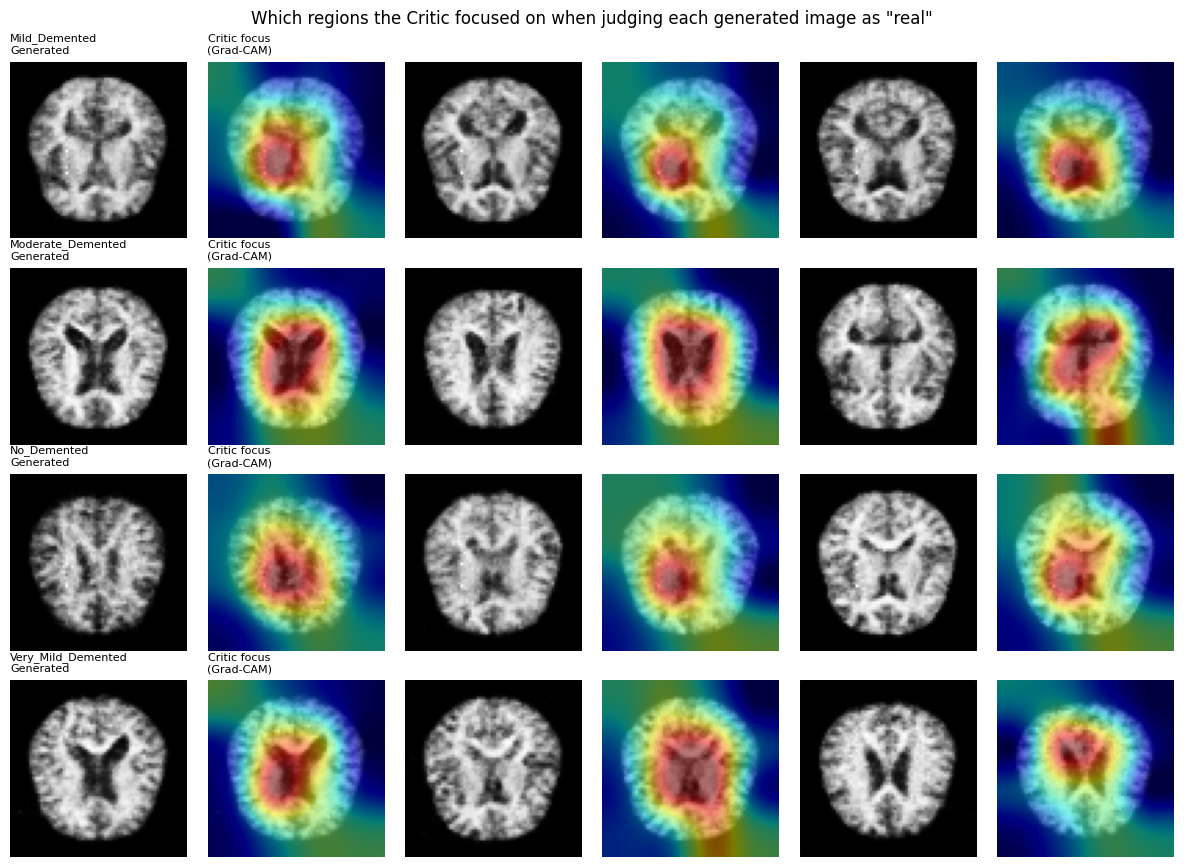


PART B: ITERATIVE REFINE LOOP
NOTE: to allow actual fine-tuning when quality is below target,
build your train_loader (same as in wgan_gp_fixed.py) and pass it:
  iterative_refine_loop(train_loader=train_loader)
Running a quality-check-only pass for now (no train_loader passed):

Caching real images for comparison...

ITERATION 1/3
Generating validation batch...
Diversity ratio per class (fake/real, target >= 0.5):
  Mild_Demented        0.932 ✅
  Moderate_Demented    0.792 ✅
  No_Demented          1.095 ✅
  Very_Mild_Demented   0.845 ✅

✅ Quality target met at iteration 1. Stopping.


True

In [ ]:
# ============================================
# FEATURE: GAN EXPLAINABILITY (Critic Grad-CAM)
# + ITERATIVE GENERATE -> VALIDATE -> REFINE LOOP
# ============================================
#
# PART A explains WHICH REGION of a generated image most influenced
# the Critic's "this looks real" score — using Grad-CAM on the Critic,
# the same underlying technique as classifier Grad-CAM, just applied
# to the Critic instead of a classifier.
#
# PART B automates: generate a batch -> run quality checks -> if not
# good enough, train the GAN a bit more -> regenerate -> recheck.
# Repeats until quality target is met or a max iteration limit hits.

from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from itertools import combinations

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class_names = ['Mild_Demented', 'Moderate_Demented', 'No_Demented', 'Very_Mild_Demented']
REAL_DATA_PATH = "/content/drive/My Drive/Alzhiemer_GAN_federated/Alzhiemer's_disease"
CHECKPOINT_PATH = '/content/drive/My Drive/Alzhiemer_GAN_federated/checkpoints_stable/wgan_gp_epoch_20.pth'

# ---------------------------------------------
# 0. MODEL CLASSES (must match training exactly)
# ---------------------------------------------
class SimpleGenerator(nn.Module):
    def __init__(self, latent_dim=100, num_classes=4):
        super(SimpleGenerator, self).__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.label_embedding = nn.Embedding(num_classes, latent_dim)
        self.fc = nn.Linear(latent_dim * 2, 256 * 4 * 4)
        self.main = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Tanh()
        )

    def forward(self, z, labels):
        label_emb = self.label_embedding(labels)
        z = torch.cat([z, label_emb], dim=1)
        out = self.fc(z)
        out = out.view(out.size(0), 256, 4, 4)
        return self.main(out)

class SimpleCritic(nn.Module):
    def __init__(self, num_classes=4, img_size=64):
        super(SimpleCritic, self).__init__()
        self.num_classes = num_classes
        self.img_size = img_size
        self.label_embedding = nn.Embedding(num_classes, img_size * img_size)
        # named layers (not just Sequential) so we can hook the last conv easily
        self.conv1 = nn.Conv2d(2, 64, 4, 2, 1)
        self.act1 = nn.LeakyReLU(0.2, True)

        self.conv2 = nn.Conv2d(64, 128, 4, 2, 1)
        self.norm2 = nn.GroupNorm(8, 128)
        self.act2 = nn.LeakyReLU(0.2, True)

        self.conv3 = nn.Conv2d(128, 256, 4, 2, 1)
        self.norm3 = nn.GroupNorm(8, 256)
        self.act3 = nn.LeakyReLU(0.2, True)

        self.conv4 = nn.Conv2d(256, 512, 4, 2, 1)   # <- last conv layer, Grad-CAM target
        self.norm4 = nn.GroupNorm(8, 512)
        self.act4 = nn.LeakyReLU(0.2, True)

        self.fc = nn.Linear(512 * 4 * 4, 1)

        self._gradients = None
        self._activations = None

    def activations_hook(self, grad):
        self._gradients = grad

    def forward(self, img, labels):
        label_emb = self.label_embedding(labels)
        label_emb = label_emb.view(label_emb.size(0), 1, self.img_size, self.img_size)
        x = torch.cat([img, label_emb], dim=1)

        x = self.act1(self.conv1(x))
        x = self.act2(self.norm2(self.conv2(x)))
        x = self.act3(self.norm3(self.conv3(x)))
        x = self.conv4(x)
        x = self.norm4(x)

        self._activations = x            # save feature maps (before the final activation)
        if x.requires_grad:
            x.register_hook(self.activations_hook)  # capture gradients flowing back here

        x = self.act4(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

# NOTE: state_dict keys from the original nn.Sequential-based critic
# (main.0, main.1, ... ) won't match this named-layer version directly.
# We remap them below so the trained weights still load correctly.
def load_critic_weights_from_sequential(critic, sequential_state_dict):
    """Maps the original Sequential critic's state_dict keys onto this
    named-layer version. Layer order is identical, only naming differs."""
    key_map = {
        'main.0.weight': 'conv1.weight', 'main.0.bias': 'conv1.bias',
        'main.2.weight': 'conv2.weight', 'main.2.bias': 'conv2.bias',
        'main.3.weight': 'norm2.weight', 'main.3.bias': 'norm2.bias',
        'main.5.weight': 'conv3.weight', 'main.5.bias': 'conv3.bias',
        'main.6.weight': 'norm3.weight', 'main.6.bias': 'norm3.bias',
        'main.8.weight': 'conv4.weight', 'main.8.bias': 'conv4.bias',
        'main.9.weight': 'norm4.weight', 'main.9.bias': 'norm4.bias',
        'label_embedding.weight': 'label_embedding.weight',
        'fc.weight': 'fc.weight', 'fc.bias': 'fc.bias',
    }
    new_state_dict = {}
    for old_key, tensor in sequential_state_dict.items():
        if old_key in key_map:
            new_state_dict[key_map[old_key]] = tensor
    missing, unexpected = critic.load_state_dict(new_state_dict, strict=False)
    if missing:
        print(f"  ⚠️ Note: some keys didn't map automatically: {missing}")
    return critic

# ---------------------------------------------
# 1. LOAD TRAINED GENERATOR + CRITIC
# ---------------------------------------------
print(f"Loading checkpoint: {CHECKPOINT_PATH}")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

generator = SimpleGenerator(latent_dim=100, num_classes=4).to(device)
generator.load_state_dict(checkpoint['generator_state_dict'])
generator.eval()

critic = SimpleCritic(num_classes=4).to(device)
load_critic_weights_from_sequential(critic, checkpoint['critic_state_dict'])
critic.eval()
print("✅ Generator and Critic loaded")

# ============================================
# PART A: CRITIC GRAD-CAM EXPLAINABILITY
# ============================================

def critic_grad_cam(fake_img, label):
    """fake_img: [1, 1, 64, 64] tensor. Returns a 64x64 heatmap showing
    which regions most influenced the Critic's realness score."""
    critic.zero_grad()
    fake_img = fake_img.clone().detach().requires_grad_(True)
    label_tensor = torch.tensor([label]).to(device)

    score = critic(fake_img, label_tensor)  # forward pass, also stores activations + registers hook
    score.backward()                         # backward pass, fills in critic._gradients

    gradients = critic._gradients[0]         # [512, 4, 4]
    activations = critic._activations[0].detach()  # [512, 4, 4]

    # Grad-CAM formula: weight each feature map channel by the average
    # gradient flowing into it, then sum — channels that mattered more
    # for the score get weighted more heavily in the final heatmap.
    weights = gradients.mean(dim=(1, 2))     # [512] -- one weight per channel
    cam = torch.zeros(activations.shape[1:], device=device)  # [4, 4]
    for c in range(activations.shape[0]):
        cam += weights[c] * activations[c]

    cam = F.relu(cam)  # only positive influence matters (Grad-CAM convention)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    cam = cam.cpu().numpy()

    # upsample from 4x4 (feature map size) to 64x64 (image size)
    cam_img = Image.fromarray((cam * 255).astype(np.uint8)).resize((64, 64), Image.BICUBIC)
    return np.array(cam_img) / 255.0

def show_gradcam_grid(n_per_class=3):
    fig, axes = plt.subplots(len(class_names), n_per_class * 2,
                              figsize=(n_per_class * 4, len(class_names) * 2.2))

    for c, cname in enumerate(class_names):
        for j in range(n_per_class):
            z = torch.randn(1, generator.latent_dim).to(device)
            label_tensor = torch.tensor([c]).to(device)
            with torch.no_grad():
                fake_img = generator(z, label_tensor)

            heatmap = critic_grad_cam(fake_img, c)
            img_np = (fake_img[0, 0].detach().cpu().numpy() + 1) / 2  # [-1,1] -> [0,1]

            col_img = j * 2
            col_overlay = j * 2 + 1

            axes[c, col_img].imshow(img_np, cmap='gray')
            axes[c, col_img].axis('off')
            if j == 0:
                axes[c, col_img].set_title(f'{cname}\nGenerated', fontsize=8, loc='left')

            axes[c, col_overlay].imshow(img_np, cmap='gray')
            axes[c, col_overlay].imshow(heatmap, cmap='jet', alpha=0.5)
            axes[c, col_overlay].axis('off')
            if j == 0:
                axes[c, col_overlay].set_title('Critic focus\n(Grad-CAM)', fontsize=8, loc='left')

    plt.suptitle('Which regions the Critic focused on when judging each generated image as "real"')
    plt.tight_layout()
    plt.savefig('/content/critic_gradcam.png', dpi=150)
    plt.show()

# ============================================
# PART B: ITERATIVE GENERATE -> VALIDATE -> REFINE LOOP
# ============================================

def diversity_score(images_np):
    flat = images_np.reshape(images_np.shape[0], -1)
    dists = [np.linalg.norm(flat[i] - flat[j]) for i, j in combinations(range(len(flat)), 2)]
    return float(np.mean(dists)) if dists else 0.0

def load_real_images(cname, max_images=50, size=(64, 64)):
    folder = os.path.join(REAL_DATA_PATH, cname)
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:max_images]
    imgs = []
    for f in files:
        img = Image.open(os.path.join(folder, f)).convert('L').resize(size)
        imgs.append(np.array(img, dtype=np.float32) / 127.5 - 1)  # match GAN's [-1,1] scale
    return np.stack(imgs)

def generate_batch_np(n_per_class):
    """Generate n_per_class images per class, return as numpy arrays keyed by class."""
    results = {}
    with torch.no_grad():
        for c, cname in enumerate(class_names):
            z = torch.randn(n_per_class, generator.latent_dim).to(device)
            labels = torch.full((n_per_class,), c, dtype=torch.long).to(device)
            imgs = generator(z, labels).cpu().numpy().squeeze(1)  # [n, 64, 64]
            results[cname] = imgs
    return results

def check_quality(generated, real_cache, diversity_ratio_threshold=0.5):
    """Returns (passed: bool, report: dict) — checks diversity ratio per class."""
    report = {}
    passed = True
    for cname in class_names:
        real_div = diversity_score(real_cache[cname])
        fake_div = diversity_score(generated[cname])
        ratio = fake_div / real_div if real_div > 0 else 0
        report[cname] = ratio
        if ratio < diversity_ratio_threshold:
            passed = False
    return passed, report

def finetune_generator_critic(extra_epochs, dataloader, lambda_gp=10, n_critic=5, lr=0.0001):
    """Continues training the already-loaded generator/critic for a few
    more epochs, using the same WGAN-GP loop as the original training."""
    optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.9))
    optimizer_C = torch.optim.Adam(critic.parameters(), lr=lr, betas=(0.5, 0.9))

    for epoch in range(extra_epochs):
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            batch_size = imgs.size(0)

            for _ in range(n_critic):
                optimizer_C.zero_grad()
                z = torch.randn(batch_size, generator.latent_dim).to(device)
                fake_imgs = generator(z, labels)

                real_score = critic(imgs, labels)
                fake_score = critic(fake_imgs.detach(), labels)

                alpha = torch.rand(batch_size, 1, 1, 1).to(device).expand_as(imgs)
                interpolated = (alpha * imgs + (1 - alpha) * fake_imgs).requires_grad_(True)
                critic_interp = critic(interpolated, labels)
                grad = torch.autograd.grad(
                    outputs=critic_interp, inputs=interpolated,
                    grad_outputs=torch.ones_like(critic_interp),
                    create_graph=True, retain_graph=True)[0]
                gp = ((grad.view(batch_size, -1).norm(2, dim=1) - 1) ** 2).mean()

                critic_loss = fake_score.mean() - real_score.mean() + lambda_gp * gp
                critic_loss.backward()
                optimizer_C.step()

            optimizer_G.zero_grad()
            z = torch.randn(batch_size, generator.latent_dim).to(device)
            fake_imgs = generator(z, labels)
            gen_loss = -critic(fake_imgs, labels).mean()
            gen_loss.backward()
            optimizer_G.step()

        print(f"    fine-tune epoch {epoch+1}/{extra_epochs} — G:{gen_loss.item():.2f} C:{critic_loss.item():.2f}")

def iterative_refine_loop(max_iterations=3, n_check_samples=20, extra_epochs_per_round=5,
                           diversity_ratio_threshold=0.5, train_loader=None):
    """The core Feature: generate -> validate -> refine, repeating until
    quality passes or max_iterations is hit."""
    print("Caching real images for comparison...")
    real_cache = {cname: load_real_images(cname, max_images=50) for cname in class_names}

    for iteration in range(1, max_iterations + 1):
        print(f"\n{'='*60}")
        print(f"ITERATION {iteration}/{max_iterations}")
        print(f"{'='*60}")

        print("Generating validation batch...")
        generated = generate_batch_np(n_check_samples)

        passed, report = check_quality(generated, real_cache, diversity_ratio_threshold)
        print("Diversity ratio per class (fake/real, target >= "
              f"{diversity_ratio_threshold}):")
        for cname, ratio in report.items():
            flag = "✅" if ratio >= diversity_ratio_threshold else "⚠️ below target"
            print(f"  {cname:<20} {ratio:.3f} {flag}")

        if passed:
            print(f"\n✅ Quality target met at iteration {iteration}. Stopping.")
            return True

        if iteration == max_iterations:
            print(f"\n⚠️ Max iterations reached without hitting target. "
                  "Consider more epochs, a bigger architecture, or more training data.")
            return False

        if train_loader is None:
            print("\n⚠️ No train_loader provided — can't fine-tune further. "
                  "Pass your train_loader to iterative_refine_loop() to enable refinement.")
            return False

        print(f"\nQuality below target — fine-tuning {extra_epochs_per_round} more epochs...")
        finetune_generator_critic(extra_epochs_per_round, train_loader)

# ============================================
# RUN
# ============================================
print("\n" + "=" * 60)
print("PART A: EXPLAINABILITY (Critic Grad-CAM)")
print("=" * 60)
show_gradcam_grid(n_per_class=3)

print("\n" + "=" * 60)
print("PART B: ITERATIVE REFINE LOOP")
print("=" * 60)
print("NOTE: to allow actual fine-tuning when quality is below target,")
print("build your train_loader (same as in wgan_gp_fixed.py) and pass it:")
print("  iterative_refine_loop(train_loader=train_loader)")
print("Running a quality-check-only pass for now (no train_loader passed):\n")
iterative_refine_loop(max_iterations=3, n_check_samples=20)

In [ ]:
# ============================================
# FEATURE 1 (MERGED): Generate N images -> save -> explain quality -> show Grad-CAM
# One button click does ALL of this:
#   1. Generate N new images per class (fresh noise, not copies)
#   2. Save to Request_00X folder in Drive
#   3. Check quality (diversity vs real images) and EXPLAIN the result in words
#   4. Show Critic Grad-CAM heatmaps on a few of the just-generated images,
#      explaining which brain regions drove the "looks real" judgment
# ============================================

from google.colab import drive
drive.mount('/content/drive')

import os
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from itertools import combinations
import ipywidgets as widgets
from IPython.display import display, clear_output

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class_names = ['Mild_Demented', 'Moderate_Demented', 'No_Demented', 'Very_Mild_Demented']
REAL_DATA_PATH = "/content/drive/My Drive/Alzhiemer_GAN_federated/Alzhiemer's_disease"
CHECKPOINT_PATH = '/content/drive/My Drive/Alzhiemer_GAN_federated/checkpoints_stable/wgan_gp_epoch_20.pth'
OUTPUT_ROOT = '/content/drive/My Drive/Alzhiemer_GAN_federated/generated_requests'
REALISM_THRESHOLD = 50.0  # if a class's realism % falls below this, auto-retry generation
MAX_RETRIES = 3             # max regeneration attempts per class before giving up

# ---------------------------------------------
# 0. MODEL CLASSES
# ---------------------------------------------
class SimpleGenerator(nn.Module):
    def __init__(self, latent_dim=100, num_classes=4):
        super(SimpleGenerator, self).__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.label_embedding = nn.Embedding(num_classes, latent_dim)
        self.fc = nn.Linear(latent_dim * 2, 256 * 4 * 4)
        self.main = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Tanh()
        )

    def forward(self, z, labels):
        label_emb = self.label_embedding(labels)
        z = torch.cat([z, label_emb], dim=1)
        out = self.fc(z)
        out = out.view(out.size(0), 256, 4, 4)
        return self.main(out)

class SimpleCritic(nn.Module):
    def __init__(self, num_classes=4, img_size=64):
        super(SimpleCritic, self).__init__()
        self.num_classes = num_classes
        self.img_size = img_size
        self.label_embedding = nn.Embedding(num_classes, img_size * img_size)
        self.conv1 = nn.Conv2d(2, 64, 4, 2, 1)
        self.act1 = nn.LeakyReLU(0.2, True)
        self.conv2 = nn.Conv2d(64, 128, 4, 2, 1)
        self.norm2 = nn.GroupNorm(8, 128)
        self.act2 = nn.LeakyReLU(0.2, True)
        self.conv3 = nn.Conv2d(128, 256, 4, 2, 1)
        self.norm3 = nn.GroupNorm(8, 256)
        self.act3 = nn.LeakyReLU(0.2, True)
        self.conv4 = nn.Conv2d(256, 512, 4, 2, 1)
        self.norm4 = nn.GroupNorm(8, 512)
        self.act4 = nn.LeakyReLU(0.2, True)
        self.fc = nn.Linear(512 * 4 * 4, 1)
        self._gradients = None
        self._activations = None

    def activations_hook(self, grad):
        self._gradients = grad

    def forward(self, img, labels):
        label_emb = self.label_embedding(labels)
        label_emb = label_emb.view(label_emb.size(0), 1, self.img_size, self.img_size)
        x = torch.cat([img, label_emb], dim=1)
        x = self.act1(self.conv1(x))
        x = self.act2(self.norm2(self.conv2(x)))
        x = self.act3(self.norm3(self.conv3(x)))
        x = self.conv4(x)
        x = self.norm4(x)
        self._activations = x
        if x.requires_grad:
            x.register_hook(self.activations_hook)
        x = self.act4(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

def load_critic_weights_from_sequential(critic, sequential_state_dict):
    key_map = {
        'main.0.weight': 'conv1.weight', 'main.0.bias': 'conv1.bias',
        'main.2.weight': 'conv2.weight', 'main.2.bias': 'conv2.bias',
        'main.3.weight': 'norm2.weight', 'main.3.bias': 'norm2.bias',
        'main.5.weight': 'conv3.weight', 'main.5.bias': 'conv3.bias',
        'main.6.weight': 'norm3.weight', 'main.6.bias': 'norm3.bias',
        'main.8.weight': 'conv4.weight', 'main.8.bias': 'conv4.bias',
        'main.9.weight': 'norm4.weight', 'main.9.bias': 'norm4.bias',
        'label_embedding.weight': 'label_embedding.weight',
        'fc.weight': 'fc.weight', 'fc.bias': 'fc.bias',
    }
    new_state_dict = {new_state_key: sequential_state_dict[old_key]
                       for old_key, new_state_key in key_map.items() if old_key in sequential_state_dict}
    critic.load_state_dict(new_state_dict, strict=False)
    return critic

# ---------------------------------------------
# 1. LOAD MODELS (once)
# ---------------------------------------------
print(f"Loading checkpoint: {CHECKPOINT_PATH}")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

generator = SimpleGenerator(latent_dim=100, num_classes=4).to(device)
generator.load_state_dict(checkpoint['generator_state_dict'])
generator.eval()

critic = SimpleCritic(num_classes=4).to(device)
load_critic_weights_from_sequential(critic, checkpoint['critic_state_dict'])
critic.eval()
print("✅ Generator and Critic loaded\n")

# ---------------------------------------------
# 2. HELPERS: request folder tracking, diversity, real image cache, Grad-CAM
# ---------------------------------------------
os.makedirs(OUTPUT_ROOT, exist_ok=True)

def get_next_request_folder():
    existing = [d for d in os.listdir(OUTPUT_ROOT) if re.match(r'Request_\d+', d)]
    if not existing:
        return os.path.join(OUTPUT_ROOT, 'Request_001')
    numbers = [int(re.search(r'\d+', d).group()) for d in existing]
    return os.path.join(OUTPUT_ROOT, f'Request_{max(numbers) + 1:03d}')

def diversity_score(images_np):
    flat = images_np.reshape(images_np.shape[0], -1)
    dists = [np.linalg.norm(flat[i] - flat[j]) for i, j in combinations(range(len(flat)), 2)]
    return float(np.mean(dists)) if dists else 0.0

# ---------------------------------------------
# CRITIC-SCORE-BASED REALISM % (replaces diversity ratio for quality check)
# ---------------------------------------------
@torch.no_grad()
def critic_avg_score(images_tensor, label):
    """images_tensor: [N, 1, 64, 64], already in [-1, 1]. Returns the
    Critic's average raw score for this batch, for one class label."""
    n = images_tensor.size(0)
    labels_t = torch.full((n,), label, dtype=torch.long).to(device)
    scores = critic(images_tensor.to(device), labels_t)
    return scores.mean().item()

def real_images_to_tensor(real_imgs_np):
    return torch.from_numpy(real_imgs_np).unsqueeze(1).float()  # [N,1,64,64]

_noise_baseline_cache = {}
def get_noise_baseline_score(label, n_samples=50):
    """Average Critic score on pure random noise images (clearly NOT
    real MRI structure) — this is our '0% real' reference point."""
    if label not in _noise_baseline_cache:
        noise_imgs = torch.rand(n_samples, 1, 64, 64) * 2 - 1  # random values in [-1, 1]
        _noise_baseline_cache[label] = critic_avg_score(noise_imgs, label)
    return _noise_baseline_cache[label]

def realism_percentage(fake_avg_score, real_avg_score, noise_avg_score):
    """Maps the generated batch's score onto a 0-100% scale:
    0%   = as unconvincing to the Critic as pure random noise
    100% = as convincing to the Critic as real images
    Values can slightly exceed this range (generated images occasionally
    scoring even higher than real ones) — we clip to keep the bar sane."""
    if real_avg_score == noise_avg_score:
        return 50.0
    pct = (fake_avg_score - noise_avg_score) / (real_avg_score - noise_avg_score) * 100
    return float(np.clip(pct, 0, 100))

_real_cache = {}
def get_real_cache(cname, max_images=50, size=(64, 64)):
    if cname not in _real_cache:
        folder = os.path.join(REAL_DATA_PATH, cname)
        files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:max_images]
        imgs = [np.array(Image.open(os.path.join(folder, f)).convert('L').resize(size), dtype=np.float32) / 127.5 - 1
                for f in files]
        _real_cache[cname] = np.stack(imgs)
    return _real_cache[cname]

def critic_grad_cam(fake_img_tensor, label):
    critic.zero_grad()
    img = fake_img_tensor.clone().detach().requires_grad_(True)
    label_tensor = torch.tensor([label]).to(device)
    score = critic(img, label_tensor)
    score.backward()
    gradients = critic._gradients[0]
    activations = critic._activations[0].detach()
    weights = gradients.mean(dim=(1, 2))
    cam = torch.zeros(activations.shape[1:], device=device)
    for c in range(activations.shape[0]):
        cam += weights[c] * activations[c]
    cam = F.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    cam_img = Image.fromarray((cam.cpu().numpy() * 255).astype(np.uint8)).resize((64, 64), Image.BICUBIC)
    return np.array(cam_img) / 255.0

# ---------------------------------------------
# 2b. RETRAIN-ON-DEMAND (asks the user, only runs if they confirm)
# ---------------------------------------------
_train_loader_cache = None

def get_train_loader(batch_size=64):
    """Lazily builds the real-image DataLoader needed for fine-tuning.
    Only built if the user actually confirms a retrain — avoids loading
    all 10,496 images on every run when it's not needed."""
    global _train_loader_cache
    if _train_loader_cache is not None:
        return _train_loader_cache

    from torch.utils.data import Dataset, DataLoader

    class MRIDataset(Dataset):
        def __init__(self, paths, labels):
            self.paths, self.labels = paths, labels
        def __len__(self):
            return len(self.paths)
        def __getitem__(self, idx):
            img = Image.open(self.paths[idx]).convert('L').resize((64, 64))
            img = np.array(img, dtype=np.float32) / 127.5 - 1
            return torch.from_numpy(img).unsqueeze(0), self.labels[idx]

    paths, labels = [], []
    for label, cname in enumerate(class_names):
        folder = os.path.join(REAL_DATA_PATH, cname)
        for f in os.listdir(folder):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                paths.append(os.path.join(folder, f))
                labels.append(label)

    dataset = MRIDataset(paths, labels)
    _train_loader_cache = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    return _train_loader_cache

def finetune_generator_critic(extra_epochs, dataloader, lambda_gp=10, n_critic=5, lr=0.0001):
    """Continues training the CURRENTLY LOADED generator/critic in place —
    same WGAN-GP loop as original training, just picking up from here."""
    optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.9))
    optimizer_C = torch.optim.Adam(critic.parameters(), lr=lr, betas=(0.5, 0.9))
    generator.train()
    critic.train()

    for epoch in range(extra_epochs):
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            batch_size = imgs.size(0)

            for _ in range(n_critic):
                optimizer_C.zero_grad()
                z = torch.randn(batch_size, generator.latent_dim).to(device)
                fake_imgs = generator(z, labels)
                real_score = critic(imgs, labels)
                fake_score = critic(fake_imgs.detach(), labels)

                alpha = torch.rand(batch_size, 1, 1, 1).to(device).expand_as(imgs)
                interpolated = (alpha * imgs + (1 - alpha) * fake_imgs).requires_grad_(True)
                critic_interp = critic(interpolated, labels)
                grad = torch.autograd.grad(
                    outputs=critic_interp, inputs=interpolated,
                    grad_outputs=torch.ones_like(critic_interp),
                    create_graph=True, retain_graph=True)[0]
                gp = ((grad.view(batch_size, -1).norm(2, dim=1) - 1) ** 2).mean()

                critic_loss = fake_score.mean() - real_score.mean() + lambda_gp * gp
                critic_loss.backward()
                optimizer_C.step()

            optimizer_G.zero_grad()
            z = torch.randn(batch_size, generator.latent_dim).to(device)
            fake_imgs = generator(z, labels)
            gen_loss = -critic(fake_imgs, labels).mean()
            gen_loss.backward()
            optimizer_G.step()

        print(f"    fine-tune epoch {epoch+1}/{extra_epochs} — G:{gen_loss.item():.2f} C:{critic_loss.item():.2f}")

    generator.eval()
    critic.eval()

def ask_retrain(failed_classes, request_folder, real_avg_by_label, noise_avg_by_label,
                 num_images_per_class, output_widget):
    """Shows Yes/No buttons. If the user confirms, fine-tunes the GAN a few
    more epochs, regenerates ONLY the failed classes, and rechecks them."""
    print("❓ Do you want to retrain (fine-tune) the GAN to try to fix this?\n")

    yes_btn = widgets.Button(description='Yes, retrain', button_style='warning', icon='refresh')
    no_btn = widgets.Button(description='No, leave as is', button_style='')
    retrain_output = widgets.Output()

    def on_yes(b):
        yes_btn.disabled = True
        no_btn.disabled = True
        with retrain_output:
            print("Building training data loader (first time only, may take a moment)...")
            train_loader = get_train_loader()

            EXTRA_EPOCHS = 5
            print(f"Fine-tuning GAN for {EXTRA_EPOCHS} more epochs...")
            finetune_generator_critic(EXTRA_EPOCHS, train_loader)
            print("✅ Fine-tuning complete. Regenerating failed classes and rechecking...\n")

            for cname in failed_classes:
                label = class_names.index(cname)
                new_imgs = generate_class_batch(label, num_images_per_class)
                new_tensor = torch.from_numpy(new_imgs).unsqueeze(1).float()
                new_avg = critic_avg_score(new_tensor, label)
                new_pct = realism_percentage(new_avg, real_avg_by_label[label], noise_avg_by_label[label])

                save_class_images(new_imgs, os.path.join(request_folder, cname))

                if new_pct >= REALISM_THRESHOLD:
                    print(f"  {cname:<20} {new_pct:.1f}% → ✅ NOW ABOVE threshold after retraining")
                else:
                    print(f"  {cname:<20} {new_pct:.1f}% → still below threshold — "
                          "may need more epochs or architecture changes")

            # Save the newly fine-tuned weights so this improvement isn't lost
            save_path = CHECKPOINT_PATH.replace('.pth', '_finetuned.pth')
            torch.save({
                'generator_state_dict': generator.state_dict(),
                'critic_state_dict': critic.state_dict(),
            }, save_path)
            print(f"\n💾 Updated weights saved to: {save_path}")

    def on_no(b):
        yes_btn.disabled = True
        no_btn.disabled = True
        with retrain_output:
            print("Okay, leaving the current batch as is.")

    yes_btn.on_click(on_yes)
    no_btn.on_click(on_no)
    display(widgets.HBox([yes_btn, no_btn]))
    display(retrain_output)

# ---------------------------------------------
# 3. THE MERGED PIPELINE
# ---------------------------------------------
@torch.no_grad()
def generate_class_batch(label, n):
    """Generates n fresh images for one class. Returns numpy array [n, 64, 64]."""
    z = torch.randn(n, generator.latent_dim).to(device)
    labels_t = torch.full((n,), label, dtype=torch.long).to(device)
    fake_imgs = generator(z, labels_t)
    return fake_imgs.cpu().numpy().squeeze(1)

def save_class_images(images_np, class_dir):
    """Saves (and OVERWRITES) the images for a class — used both on first
    generation and whenever a retry replaces an earlier weak batch."""
    os.makedirs(class_dir, exist_ok=True)
    for i, img in enumerate(images_np):
        img_uint8 = (((img + 1) / 2) * 255).astype(np.uint8)
        Image.fromarray(img_uint8).save(os.path.join(class_dir, f'generated_{i+1}.png'))

def generate_explain_and_save(num_images_per_class, output_widget):
    with output_widget:
        clear_output()
        request_folder = get_next_request_folder()
        os.makedirs(request_folder, exist_ok=True)
        print(f"📁 Saving into: {request_folder}\n")

        all_generated = {}  # keep numpy arrays in memory too, for Grad-CAM later

        # --- STEP 1: GENERATE + SAVE ---
        print("=" * 60)
        print(f"STEP 1: Generating {num_images_per_class} new images per class")
        print("=" * 60)
        for label, cname in enumerate(class_names):
            class_dir = os.path.join(request_folder, cname)
            fake_imgs_np = generate_class_batch(label, num_images_per_class)
            all_generated[cname] = fake_imgs_np
            save_class_images(fake_imgs_np, class_dir)
            print(f"  ✅ {cname}: {num_images_per_class} images saved")

        # --- STEP 2: CRITIC-SCORE-BASED REALISM CHECK + CONFIDENCE BAR ---
        print(f"\n{'=' * 60}")
        print("STEP 2: Quality check — how 'real' does the Critic find this batch?")
        print("=" * 60)
        print("Method: the Critic (trained specifically to tell real MRIs apart")
        print("from fake ones) scores this generated batch, and we compare that")
        print("score against two reference points:")
        print("  100% = average score the Critic gives to REAL images")
        print("    0% = average score the Critic gives to PURE RANDOM NOISE")
        print("This tells us how convincing the generated batch is, on a scale")
        print("anchored to what the Critic actually considers real vs obviously fake.\n")

        realism_results = {}
        retry_log = {}       # cname -> number of retries used
        failed_classes = []  # classes still below threshold after MAX_RETRIES
        real_avg_by_label = {}
        noise_avg_by_label = {}

        for label, cname in enumerate(class_names):
            real_imgs_np = get_real_cache(cname)
            real_tensor = real_images_to_tensor(real_imgs_np)
            real_avg = critic_avg_score(real_tensor, label)
            noise_avg = get_noise_baseline_score(label)
            real_avg_by_label[label] = real_avg
            noise_avg_by_label[label] = noise_avg

            fake_imgs_np = all_generated[cname]
            fake_tensor = torch.from_numpy(fake_imgs_np).unsqueeze(1).float()
            fake_avg = critic_avg_score(fake_tensor, label)
            pct = realism_percentage(fake_avg, real_avg, noise_avg)

            attempts_used = 0
            best_pct, best_imgs = pct, fake_imgs_np

            # --- AUTO-RETRY: if below threshold, regenerate this class and recheck ---
            while best_pct < REALISM_THRESHOLD and attempts_used < MAX_RETRIES:
                attempts_used += 1
                print(f"  ↻ {cname}: {best_pct:.1f}% < {REALISM_THRESHOLD}% threshold — "
                      f"retry {attempts_used}/{MAX_RETRIES} (regenerating with new noise)...")

                retry_imgs_np = generate_class_batch(label, num_images_per_class)
                retry_tensor = torch.from_numpy(retry_imgs_np).unsqueeze(1).float()
                retry_avg = critic_avg_score(retry_tensor, label)
                retry_pct = realism_percentage(retry_avg, real_avg, noise_avg)
                print(f"    → retry {attempts_used} result: {retry_pct:.1f}%")

                if retry_pct > best_pct:
                    best_pct, best_imgs = retry_pct, retry_imgs_np

            if attempts_used > 0:
                retry_log[cname] = attempts_used
                all_generated[cname] = best_imgs
                save_class_images(best_imgs, os.path.join(request_folder, cname))

            realism_results[cname] = best_pct

            if best_pct >= REALISM_THRESHOLD:
                note = f" (passed after {attempts_used} retries)" if attempts_used else ""
                print(f"  {cname:<20} {best_pct:.1f}% → ✅ ABOVE {REALISM_THRESHOLD}% threshold{note}")
            else:
                failed_classes.append(cname)
                print(f"  {cname:<20} {best_pct:.1f}% → ❌ STILL BELOW {REALISM_THRESHOLD}% "
                      f"threshold after {attempts_used} retries")

        print()
        if not failed_classes:
            print(f"📋 All classes are above the {REALISM_THRESHOLD}% realism threshold. "
                  "Batch is ready to use.")
        else:
            print(f"📋 These classes are still below {REALISM_THRESHOLD}% even after "
                  f"{MAX_RETRIES} retries: {', '.join(failed_classes)}")
            print("   Retrying with new noise can only fix bad luck — it can't fix a class")
            print("   the Generator's weights consistently produce weaker images for.")
            print("   That needs actual GAN training to improve.\n")
            ask_retrain(failed_classes, request_folder, real_avg_by_label, noise_avg_by_label,
                        num_images_per_class, output_widget)

        # --- STEP 3: EXPLAINABILITY — WHICH REGION DROVE THE "LOOKS REAL" SCORE ---
        print(f"\n{'=' * 60}")
        print("STEP 3: Explainability — which brain region convinced the Critic")
        print("=" * 60)
        print("For one sample image per class, showing a heatmap of which region")
        print("of the image most influenced the Critic's real/fake judgment.")
        print("Red/yellow = strongly influenced the score. Blue = little influence.\n")

        fig, axes = plt.subplots(len(class_names), 2, figsize=(5, len(class_names) * 2.3))
        with torch.no_grad():
            sample_imgs = {}
            for label, cname in enumerate(class_names):
                z = torch.randn(1, generator.latent_dim).to(device)
                label_t = torch.tensor([label]).to(device)
                sample_imgs[cname] = generator(z, label_t)

        for row, (cname, img_tensor) in enumerate(sample_imgs.items()):
            label = class_names.index(cname)
            heatmap = critic_grad_cam(img_tensor, label)
            img_np = (img_tensor[0, 0].detach().cpu().numpy() + 1) / 2

            axes[row, 0].imshow(img_np, cmap='gray')
            axes[row, 0].axis('off')
            axes[row, 0].set_title(f'{cname}\nGenerated', fontsize=8, loc='left')

            axes[row, 1].imshow(img_np, cmap='gray')
            axes[row, 1].imshow(heatmap, cmap='jet', alpha=0.5)
            axes[row, 1].axis('off')
            axes[row, 1].set_title('Critic focus area', fontsize=8, loc='left')

        plt.tight_layout()
        plt.savefig(os.path.join(request_folder, 'explainability_sample.png'), dpi=150)
        plt.show()

        print(f"\n✅ ALL DONE. Images + quality report + explainability image saved under:")
        print(f"   {request_folder}")

# ---------------------------------------------
# 4. UI
# ---------------------------------------------
num_input = widgets.IntText(
    value=100,
    description='Number of images per class:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='320px')
)
generate_button = widgets.Button(description='Generate + Explain', button_style='success', icon='magic')
output_area = widgets.Output()

def on_click(b):
    n = num_input.value
    if n <= 0:
        with output_area:
            clear_output()
            print("⚠️ Please enter a number greater than 0.")
        return
    generate_button.disabled = True
    generate_button.description = 'Working...'
    try:
        generate_explain_and_save(n, output_area)
    finally:
        generate_button.disabled = False
        generate_button.description = 'Generate + Explain'

generate_button.on_click(on_click)
display(widgets.VBox([num_input, generate_button, output_area]))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Loading checkpoint: /content/drive/My Drive/Alzhiemer_GAN_federated/checkpoints_stable/wgan_gp_epoch_20.pth
✅ Generator and Critic loaded

